All libraries loaded. RHA beige theme active.
Dataset created: 300 restaurants | 120 shelters

-- Restaurant sample --
restaurant_id      city  latitude  longitude food_type  surplus_kg  avail_hour  day_of_week  is_weekend  num_past_donations
         R001     Cairo   29.6692    31.4570   Produce      100.55          22            1           0                   5
         R002     Lagos    6.6332     3.2861     Dairy       16.09          19            2           0                   4
         R003 Sao Paulo  -23.6986   -46.7179   Produce       45.02          17            0           0                  28

-- Shelter sample --
shelter_id   city  latitude  longitude  demand_kg  capacity_kg  residents  fill_rate  urgency
      S001  Dhaka   23.7016    90.5386      24.45        35.20        180     0.6947        1
      S002  Cairo   30.1298    31.3736      37.57        81.85         80     0.4590        0
      S003 Mumbai   18.9102    72.6237      64.91       110.58        117     0.5

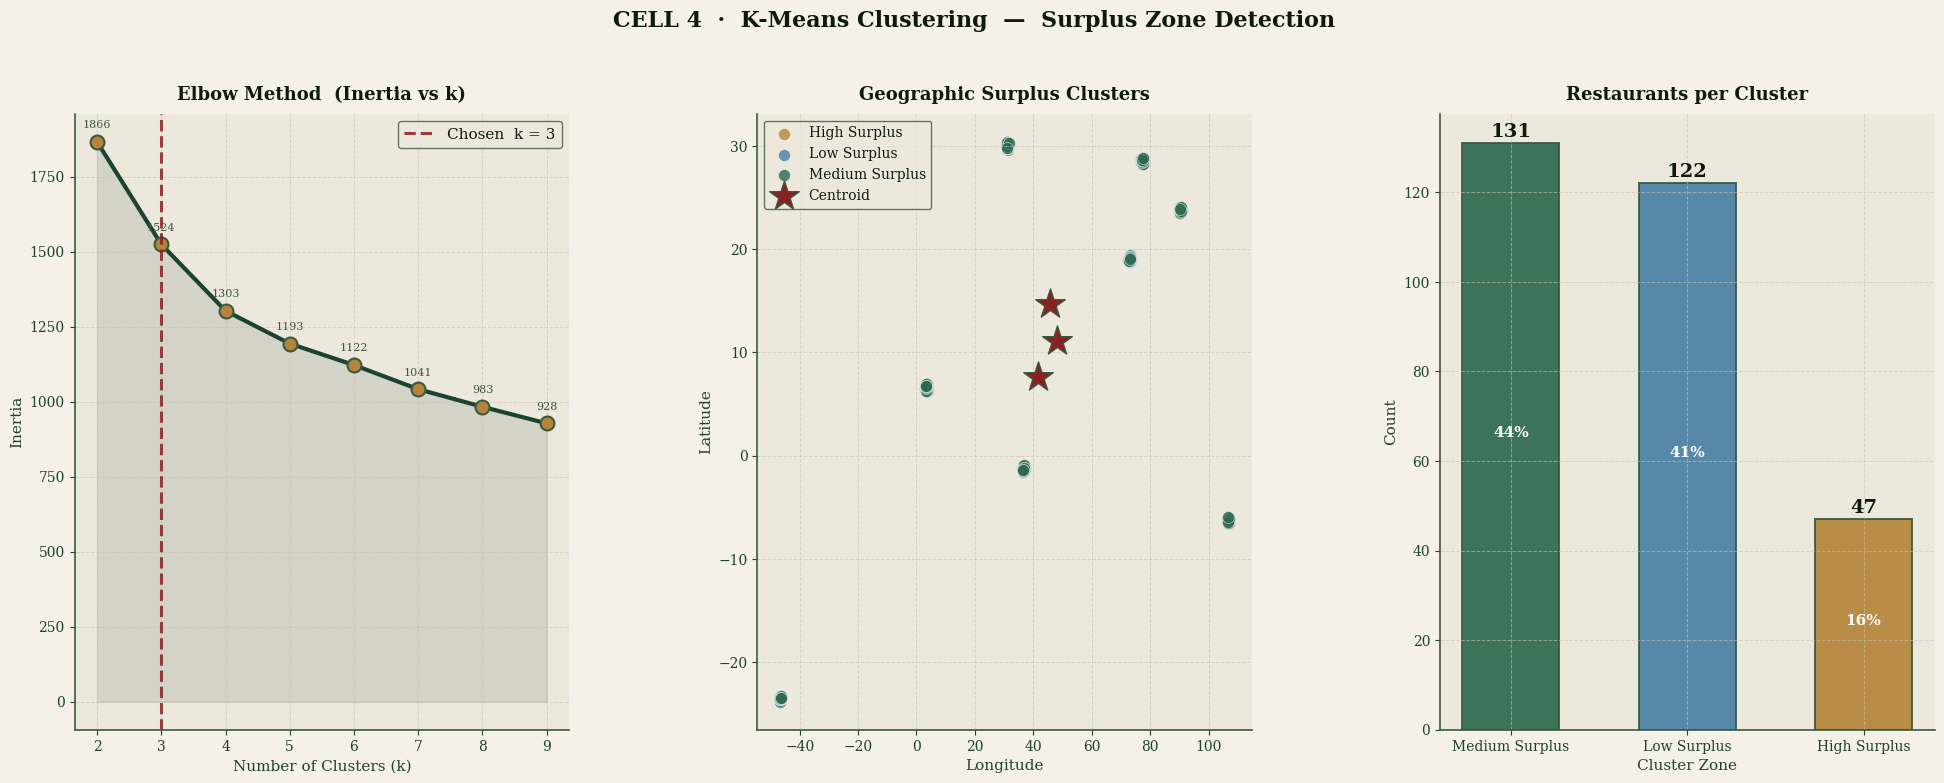

K-Means complete.
cluster_label
Medium Surplus    131
Low Surplus       122
High Surplus       47


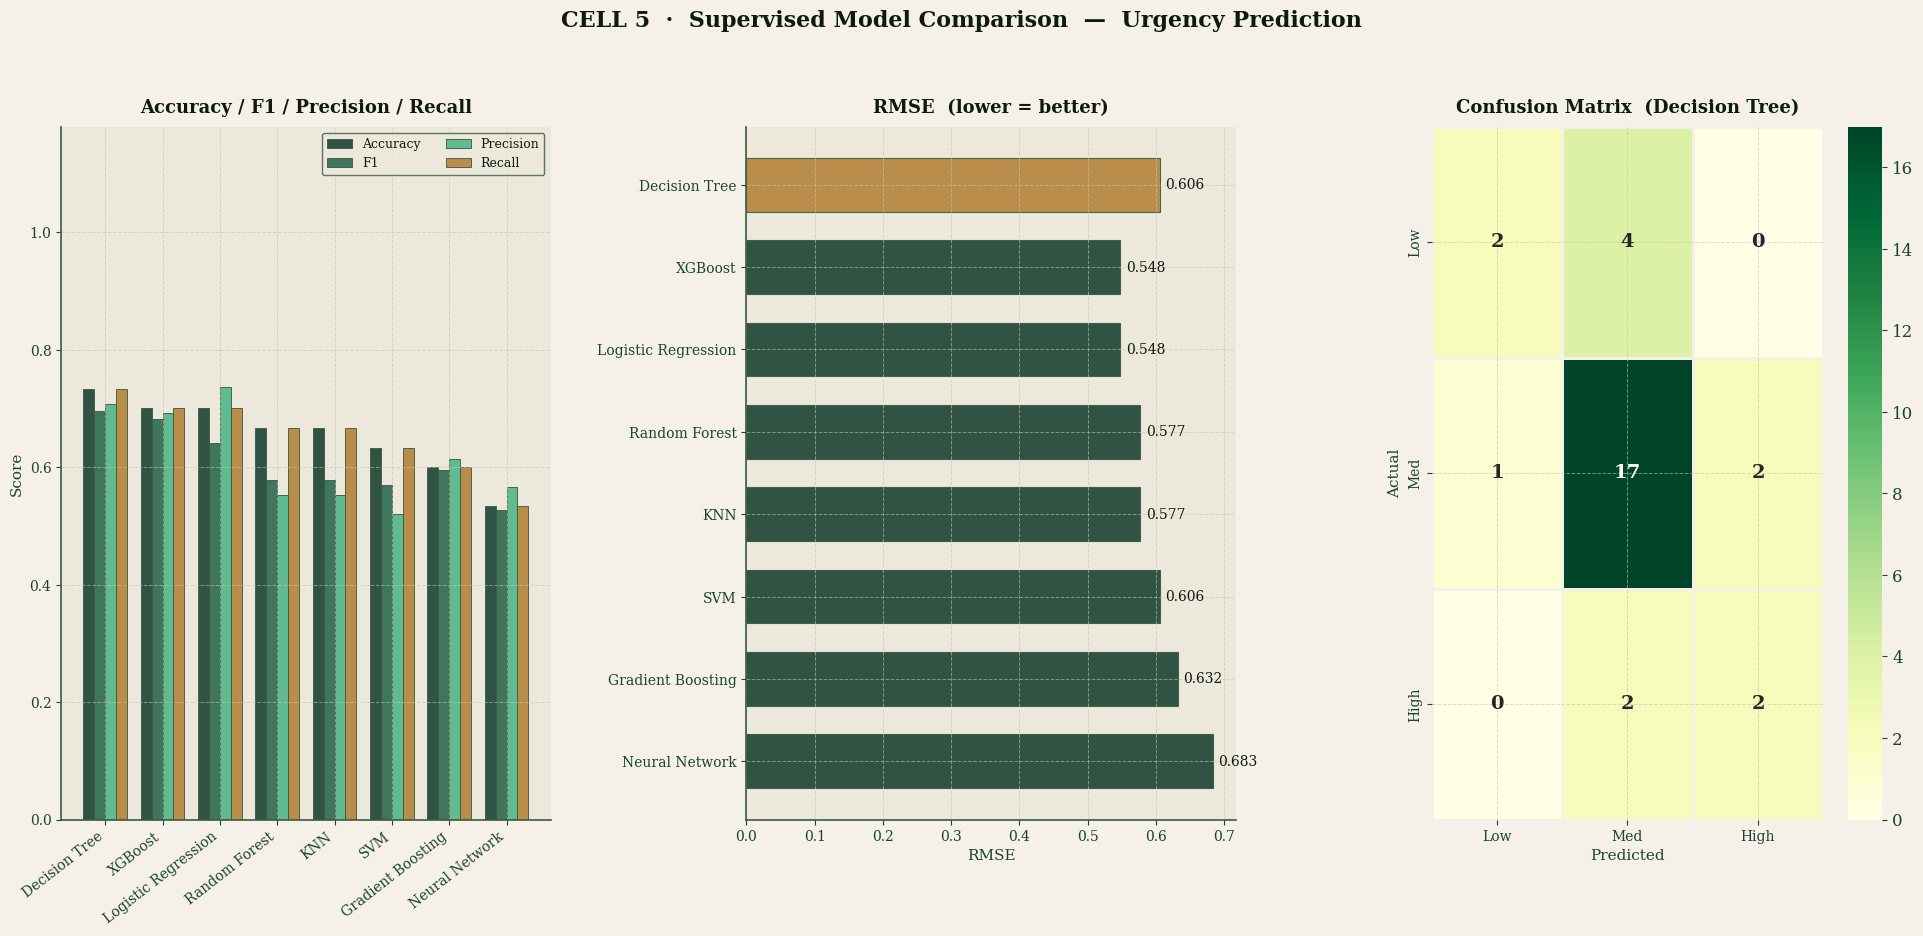

Model results:
                     Accuracy      F1  Precision  Recall    RMSE
Decision Tree          0.7333  0.6963     0.7067  0.7333  0.6055
XGBoost                0.7000  0.6827     0.6928  0.7000  0.5477
Logistic Regression    0.7000  0.6406     0.7358  0.7000  0.5477
Random Forest          0.6667  0.5778     0.5524  0.6667  0.5774
KNN                    0.6667  0.5778     0.5524  0.6667  0.5774
SVM                    0.6333  0.5704     0.5200  0.6333  0.6055
Gradient Boosting      0.6000  0.5947     0.6145  0.6000  0.6325
Neural Network         0.5333  0.5278     0.5667  0.5333  0.6831
Bipartite graph built.
  Nodes : 420  (300 restaurants + 120 shelters)
  Edges : 1500


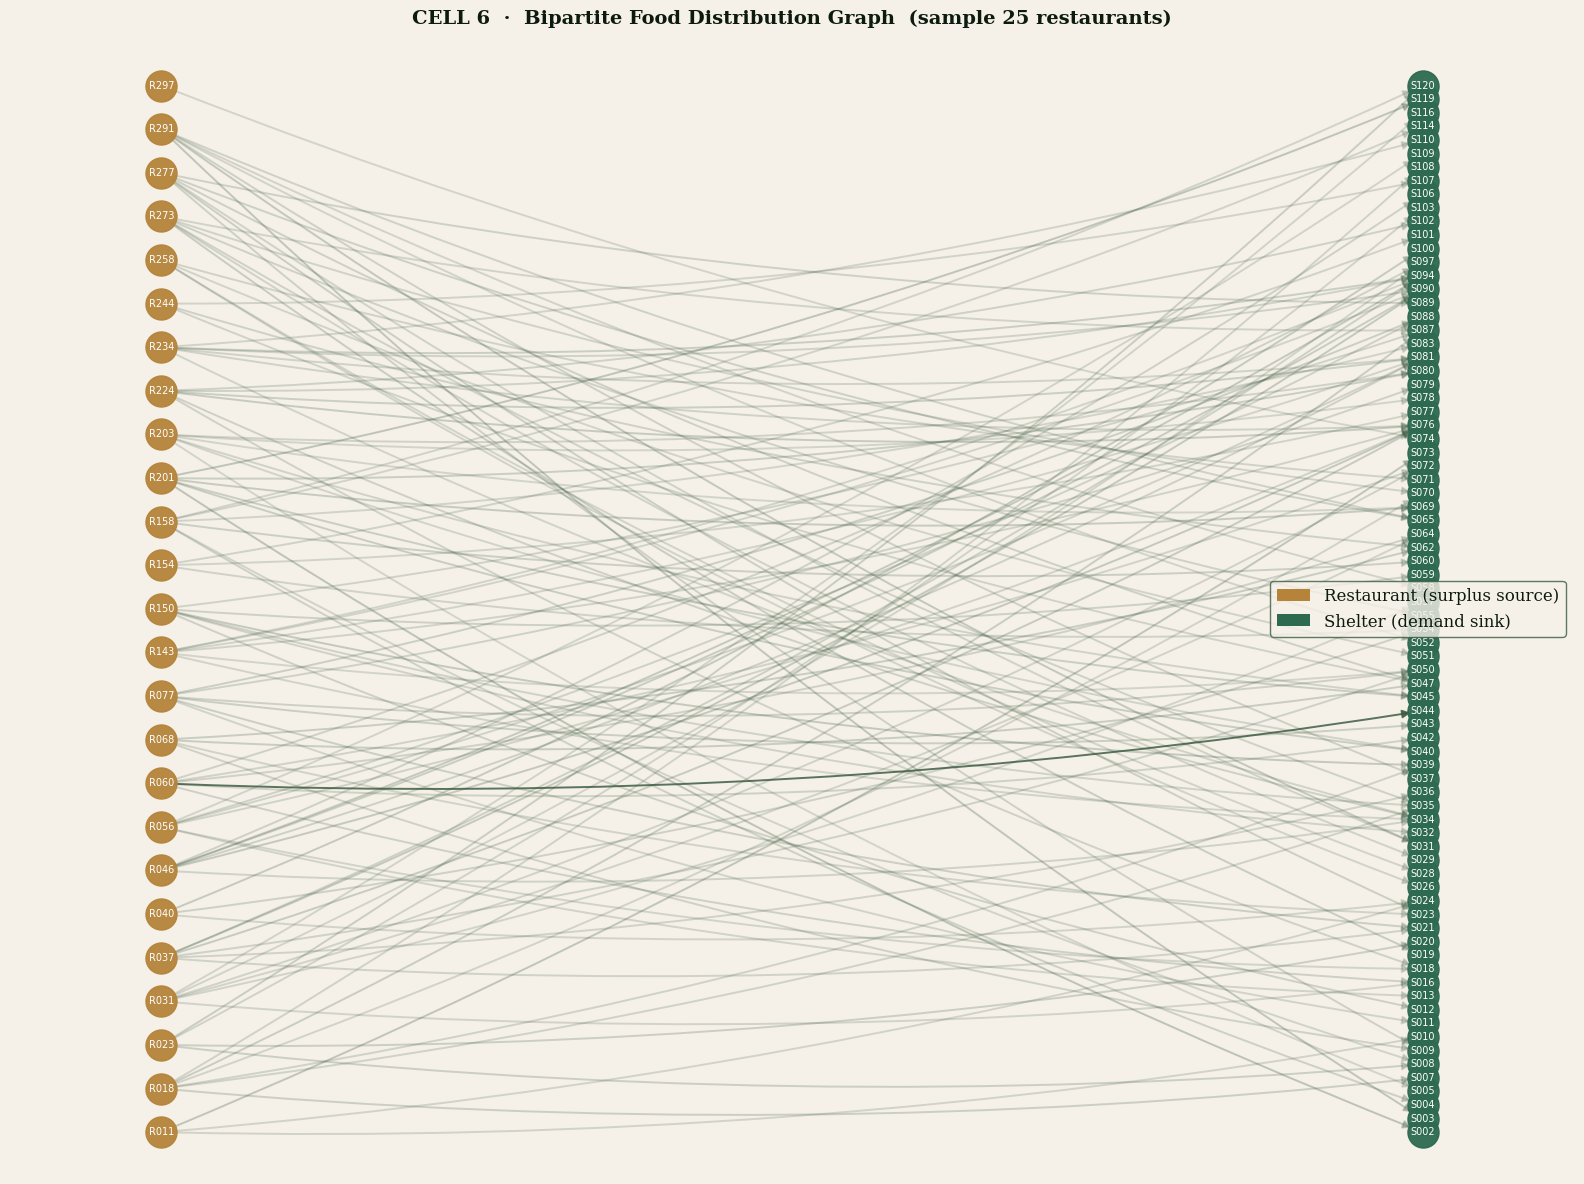

Ford-Fulkerson complete.
  Total food flow  : 5428.9 kg
  Augmenting paths : 238
  Assignments      : 244


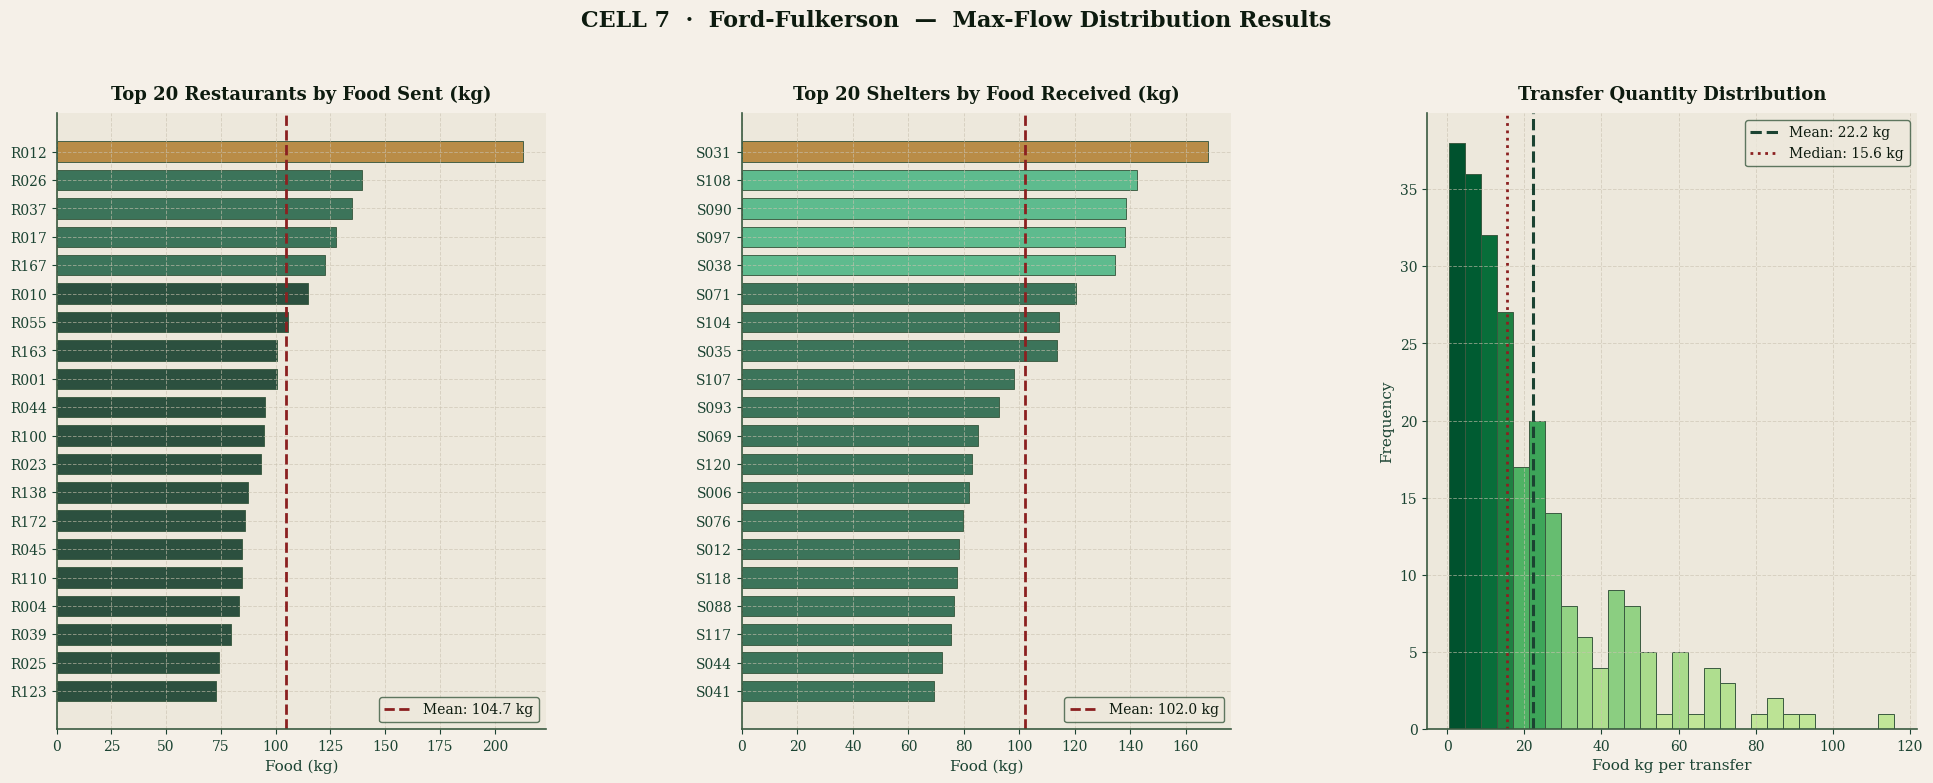

Hopcroft-Karp: 117 pairs matched


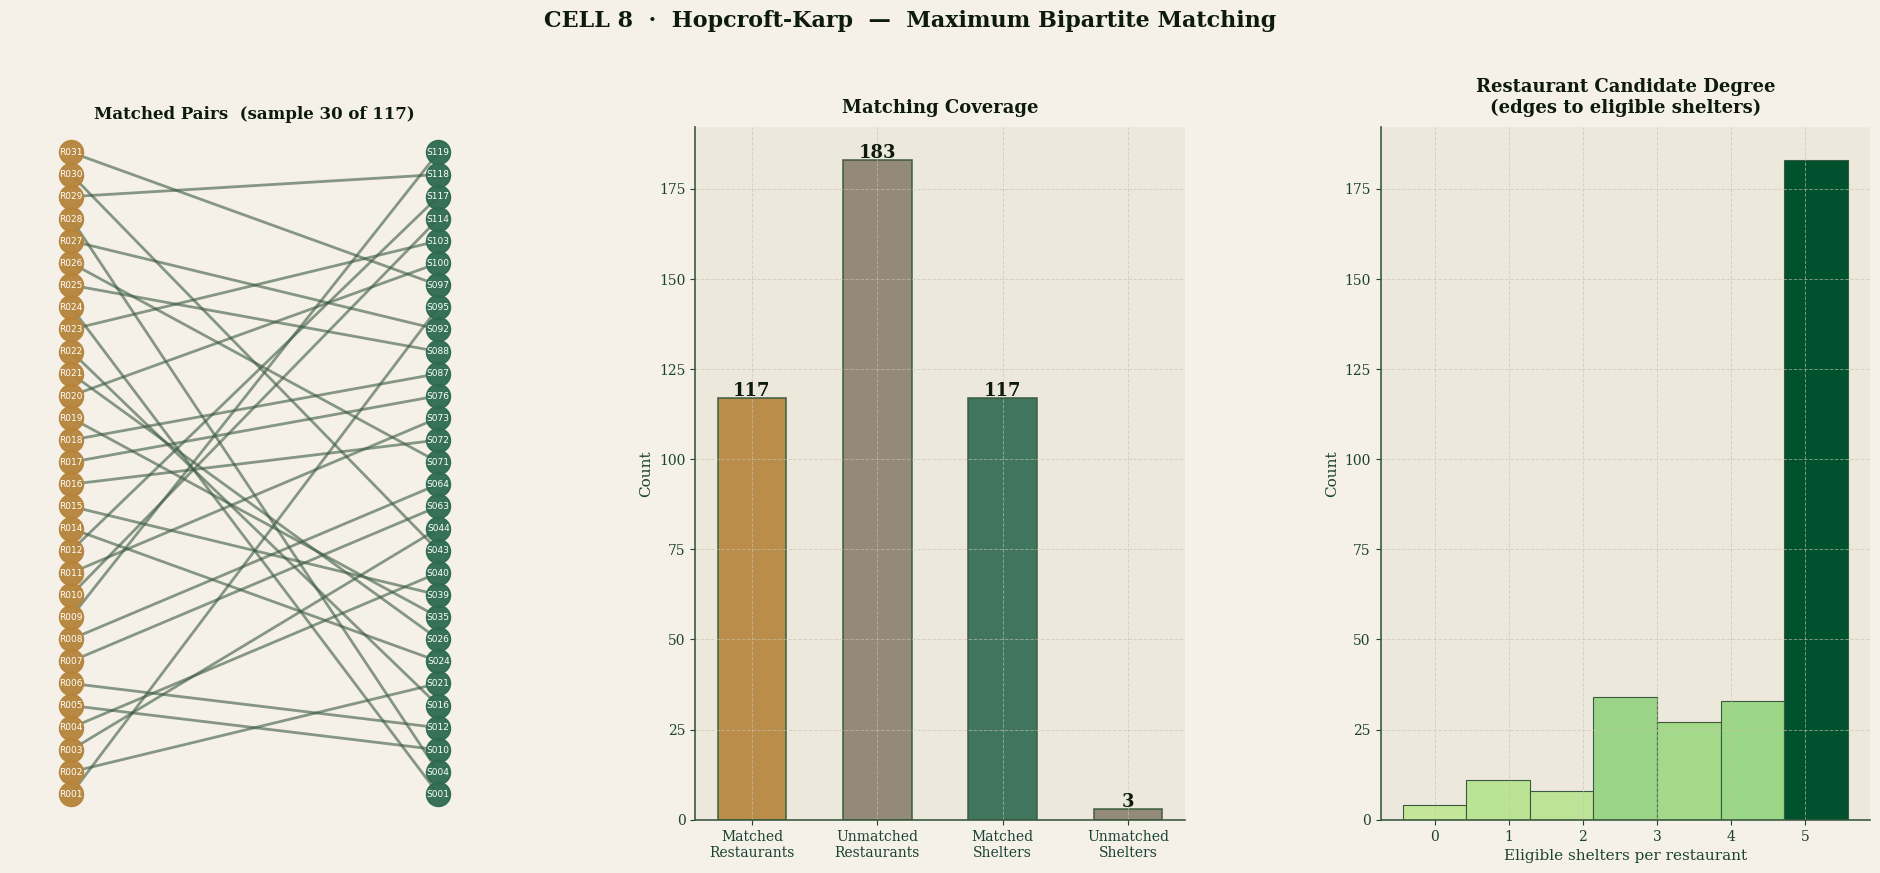

Dinic's: 5428.9 kg  |  2 BFS phases


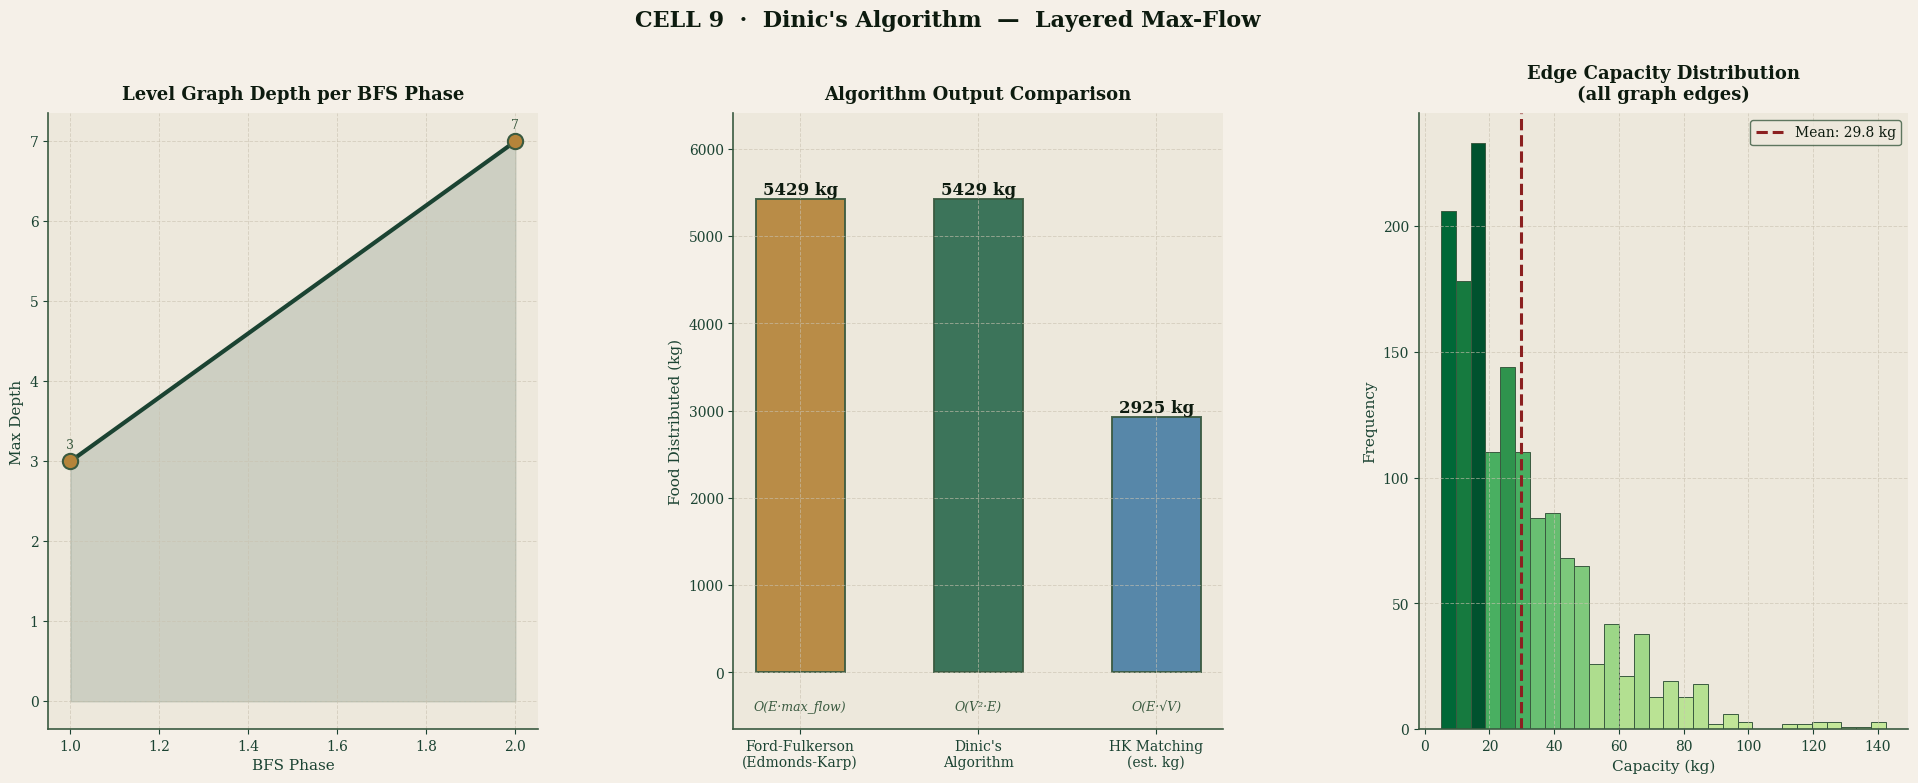

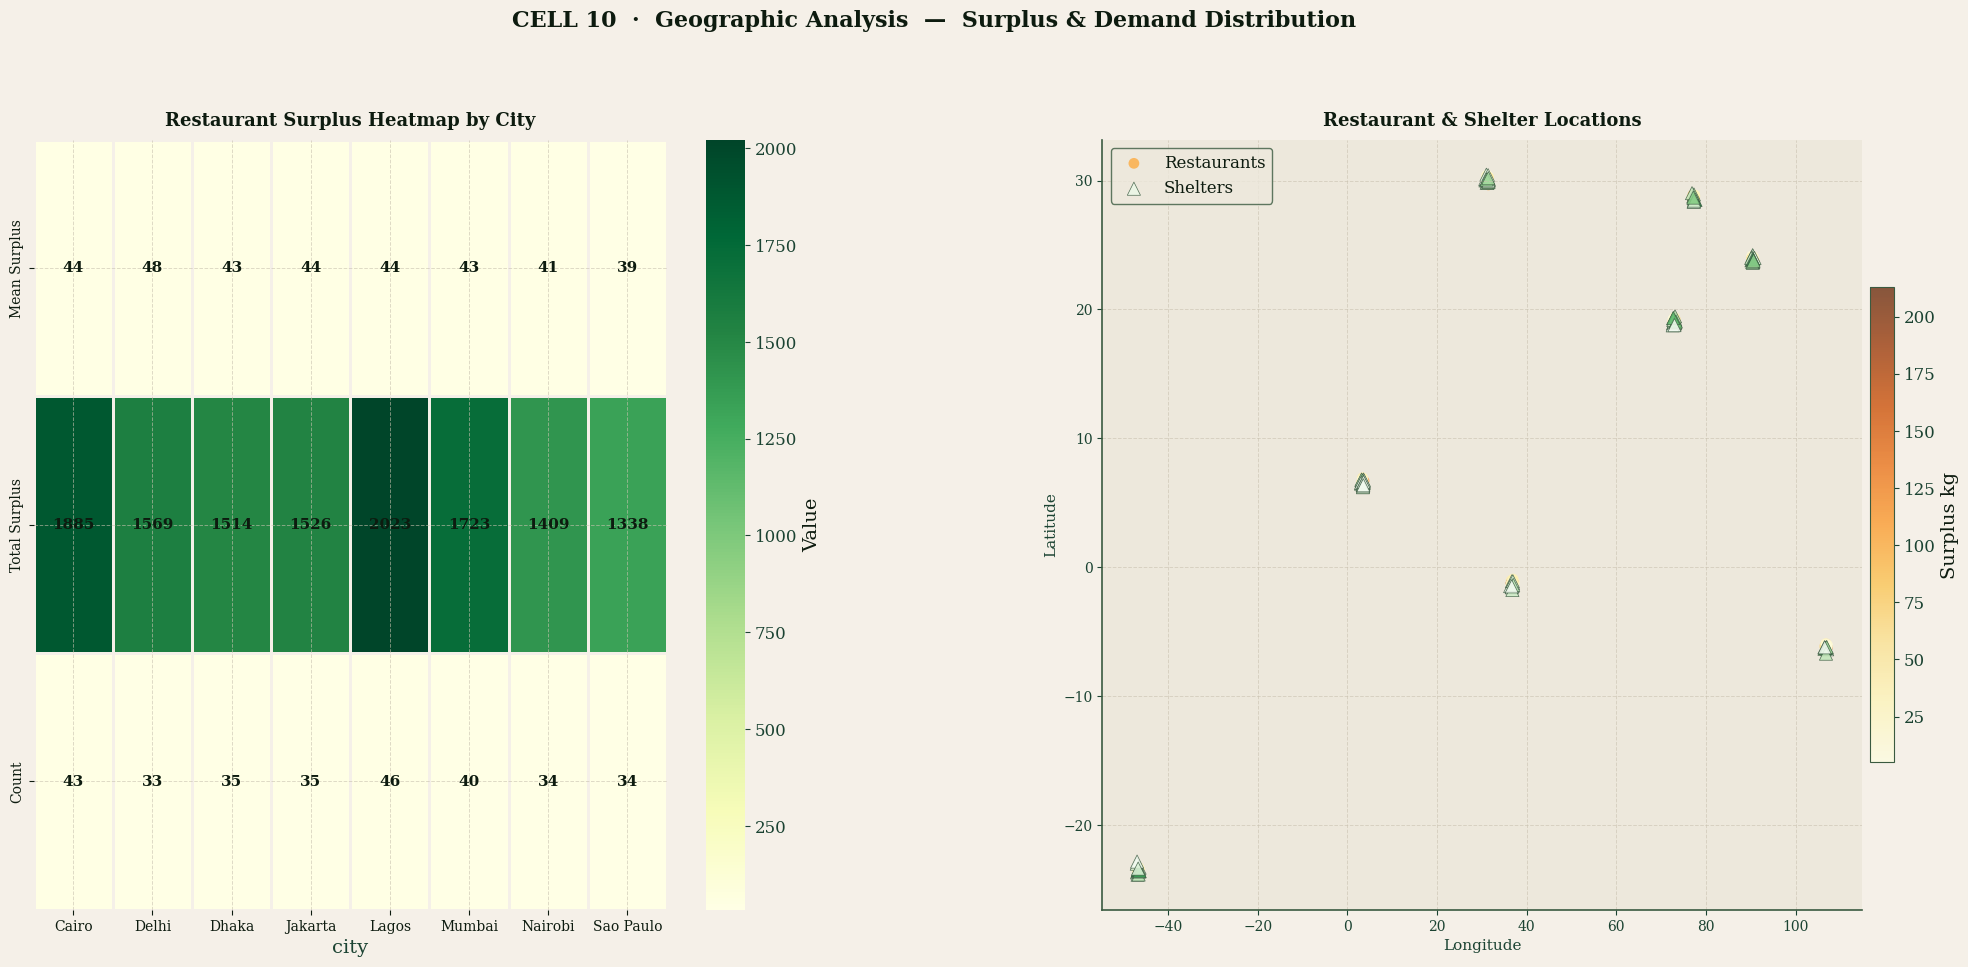

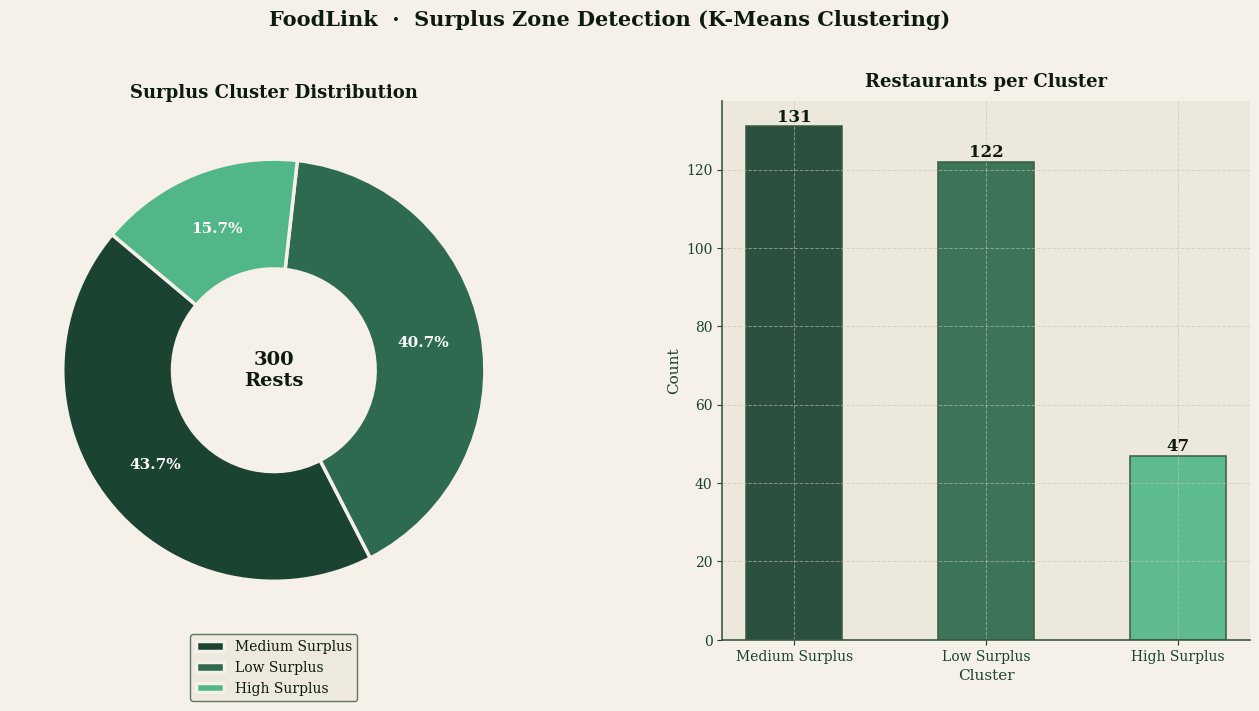

Chart 1 saved: rha_01_clusters.png


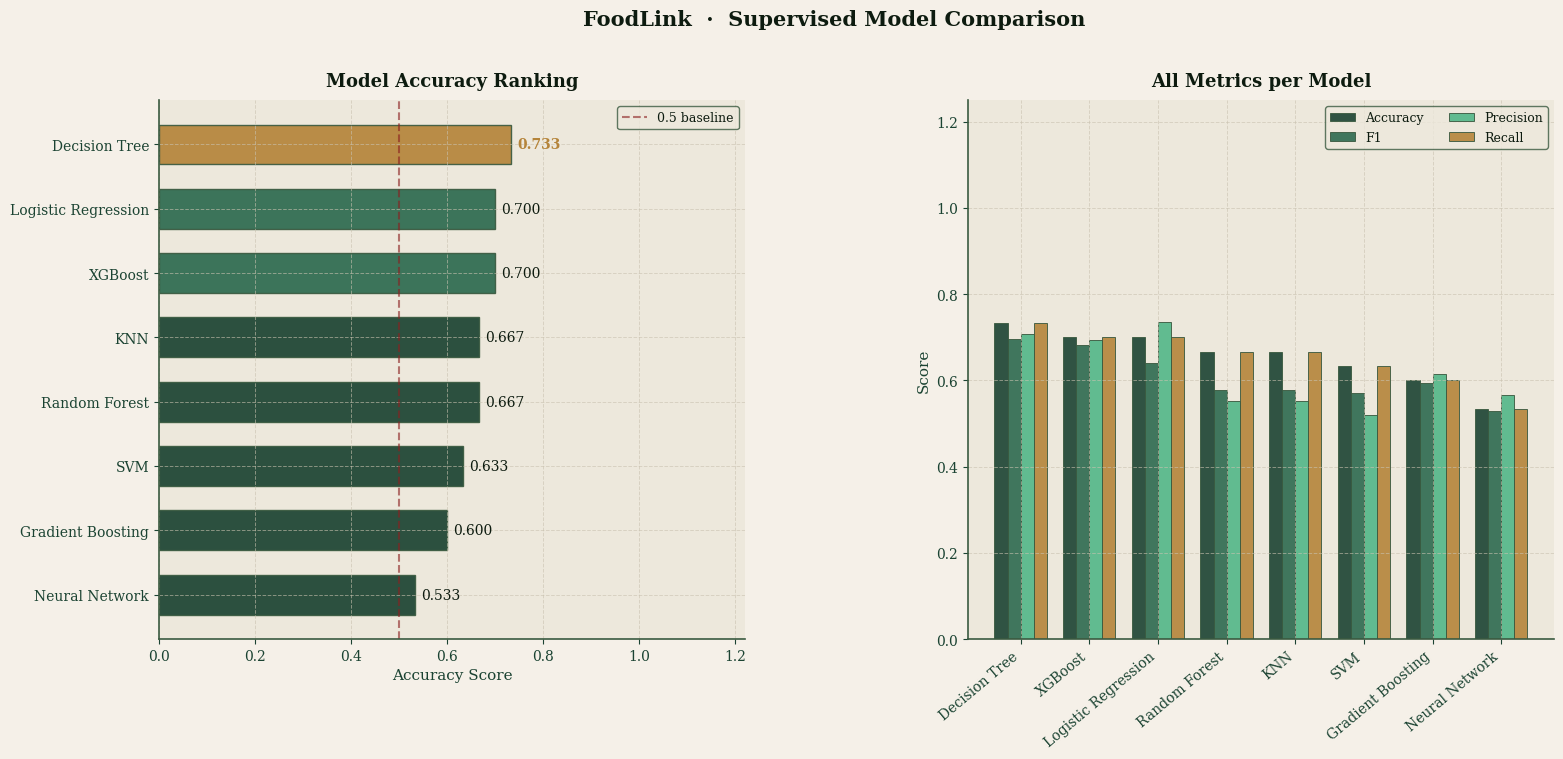

Chart 2 saved: rha_02_models.png


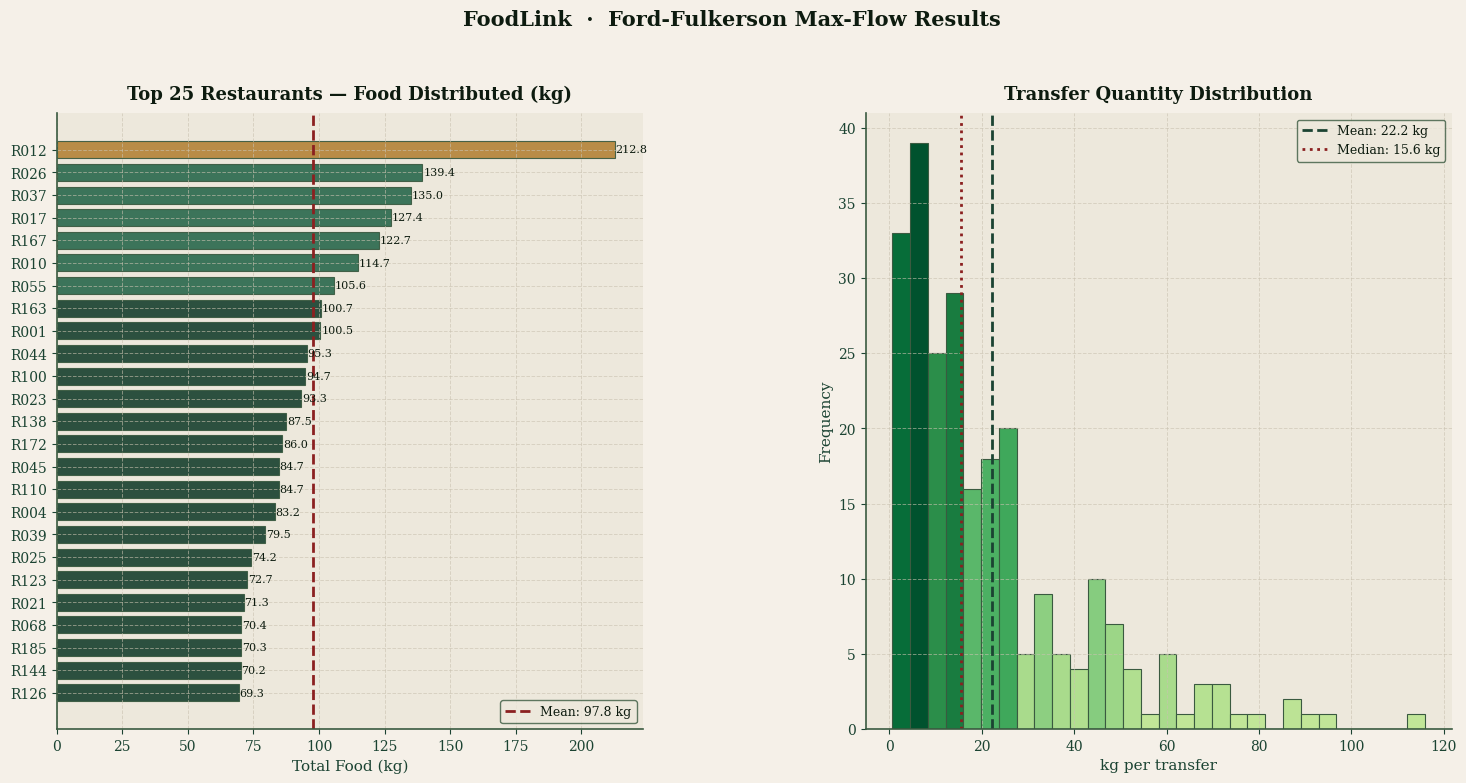

Chart 3 saved: rha_03_ford_fulkerson.png


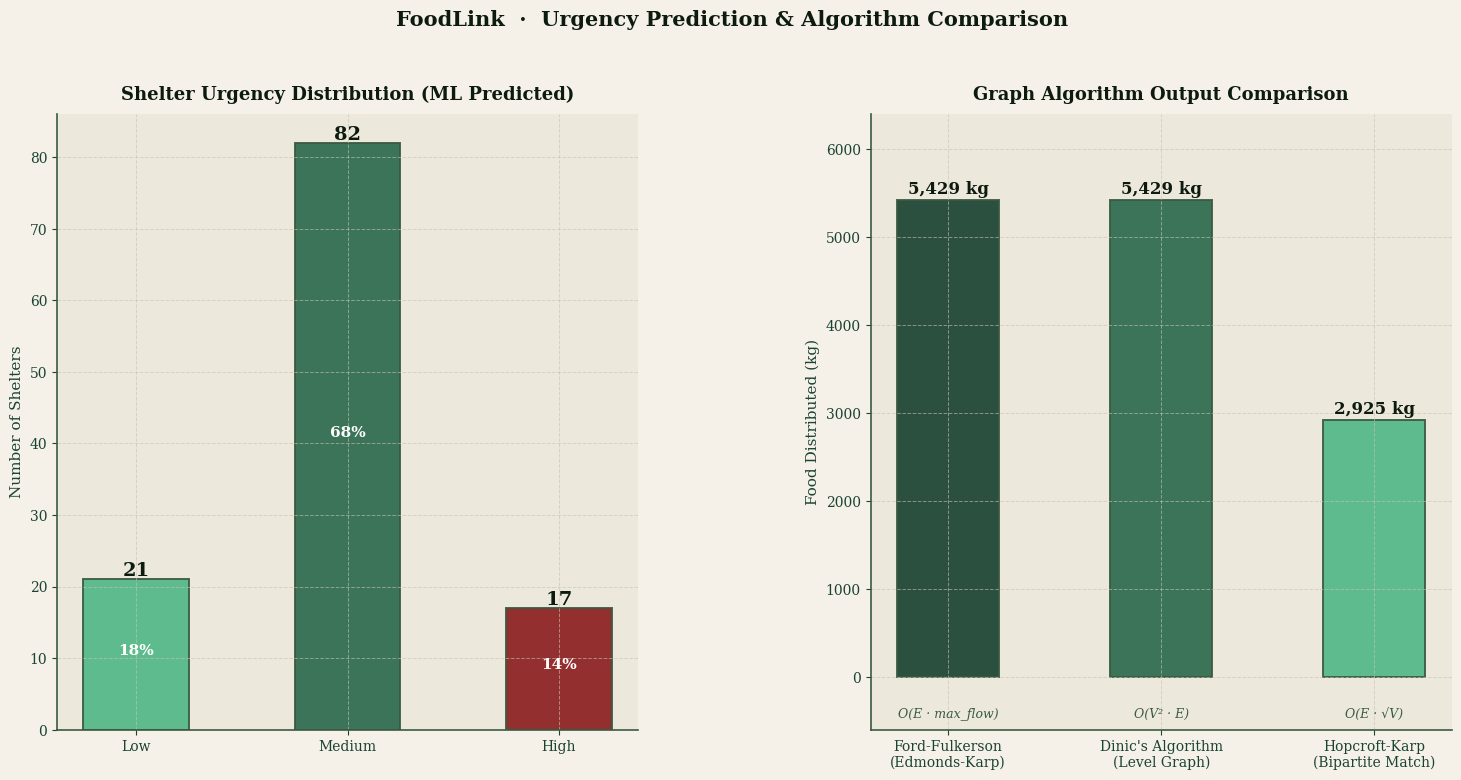

Chart 4 saved: rha_04_algorithms.png


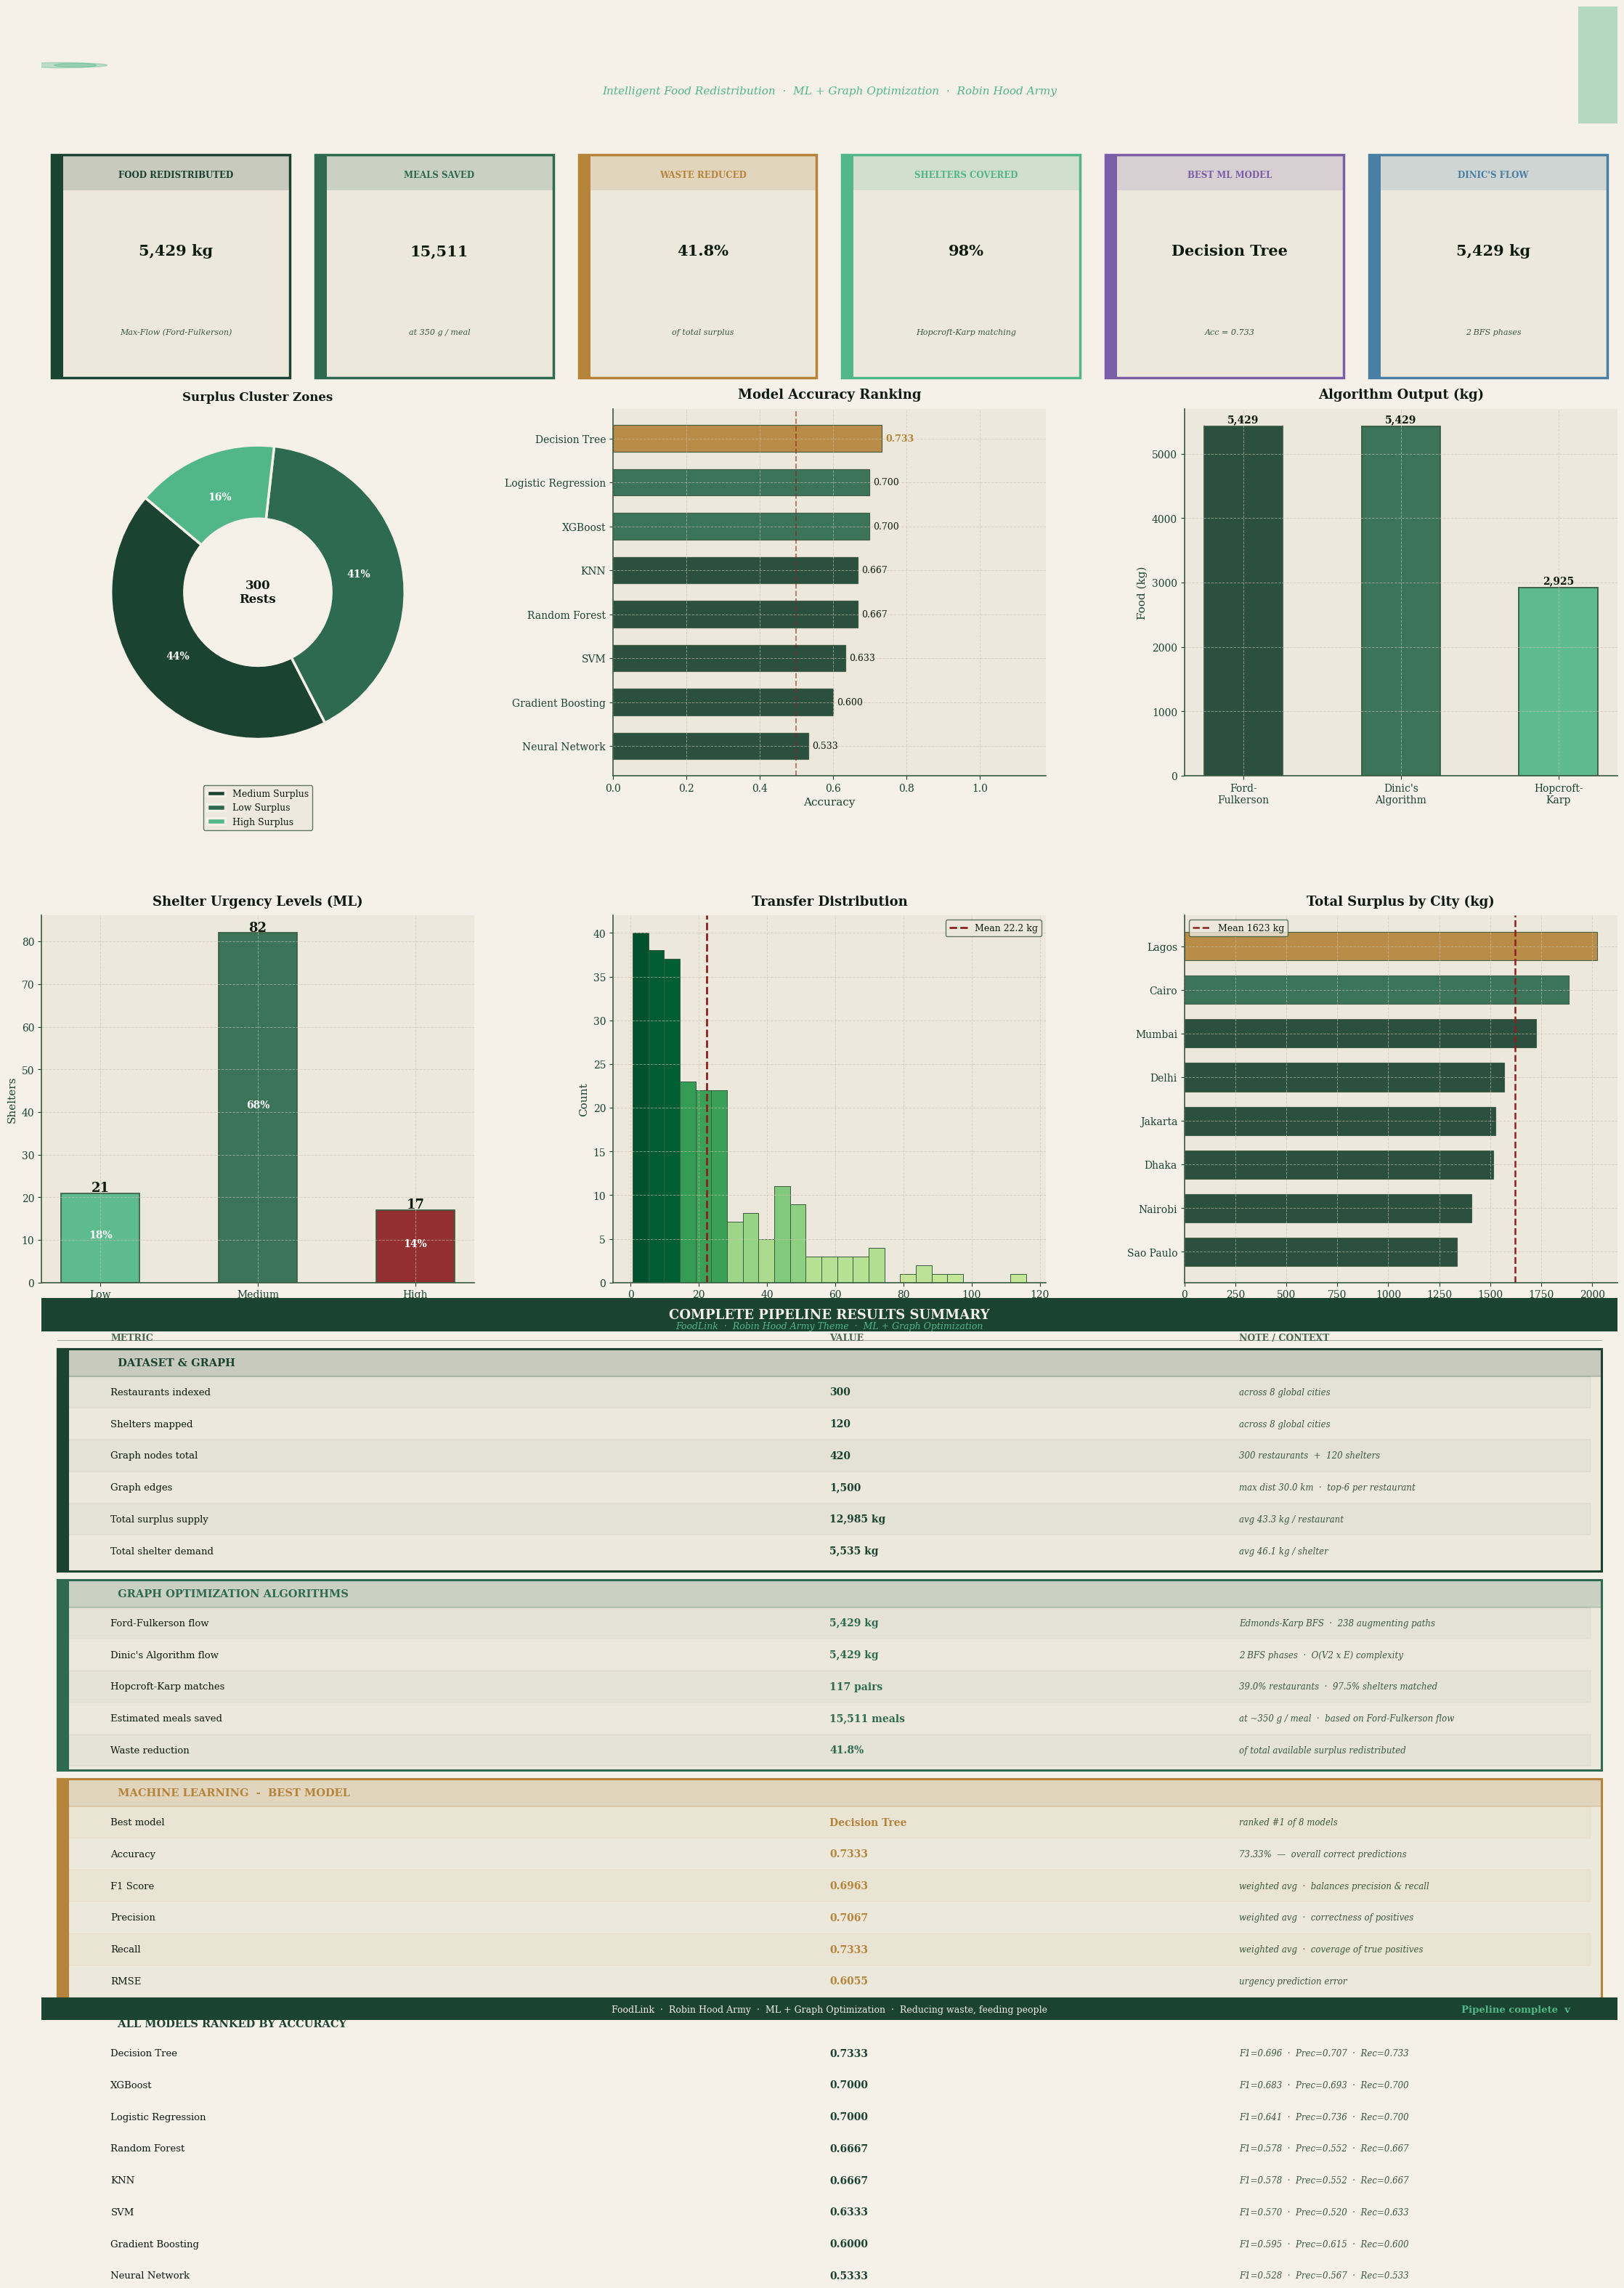


FoodLink dashboard complete!
Saved: foodlink_dashboard.png  |  rha_05_summary_table.png


In [ ]:
# =============================================================================
# FOODLINK - Intelligent Food Redistribution System
# =============================================================================

# -----------------------------------------------------------------------------
# CELL 1 - Install & Import Dependencies
# -----------------------------------------------------------------------------
# !pip install networkx scikit-learn xgboost matplotlib seaborn pandas numpy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, mean_squared_error, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from collections import defaultdict, deque
from math import radians, sin, cos, sqrt, atan2

# Global plot style
plt.rcParams.update({
    'figure.facecolor': '#0d0d0b',
    'axes.facecolor':   '#141410',
    'axes.edgecolor':   '#3a3520',
    'axes.labelcolor':  '#e8e4d8',
    'axes.titlesize':   13,
    'xtick.color':      '#857e6a',
    'ytick.color':      '#857e6a',
    'text.color':       '#e8e4d8',
    'grid.color':       '#2a2a1e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.family':      'monospace',
    'legend.facecolor': '#141410',
    'legend.edgecolor': '#3a3520',
    'legend.labelcolor':'#e8e4d8',
})


RH_BEIGE       = '#F5F0E8'
RH_PANEL       = '#EDE8DC'
RH_GREEN       = '#1B4332'
RH_MID_GREEN   = '#2D6A4F'
RH_LIGHT_GREEN = '#52B788'
RH_BLACK       = '#0D1B0F'
RH_BORDER      = '#3A5A40'
RH_GOLD        = '#B5843A'
RH_RED         = '#8B2020'
RH_GRID        = '#C9C2B0'
RH_AMBER       = '#B5843A'

# Override ALL default plot styles to beige theme
plt.rcParams.update({
    'figure.facecolor':   RH_BEIGE,
    'axes.facecolor':     RH_PANEL,
    'axes.edgecolor':     RH_BORDER,
    'axes.labelcolor':    RH_BLACK,
    'axes.titlesize':     13,
    'axes.titlecolor':    RH_BLACK,
    'xtick.color':        RH_GREEN,
    'ytick.color':        RH_GREEN,
    'text.color':         RH_BLACK,
    'grid.color':         RH_GRID,
    'grid.linestyle':     '--',
    'grid.alpha':         0.5,
    'font.family':        'DejaVu Serif',
    'legend.facecolor':   RH_PANEL,
    'legend.edgecolor':   RH_BORDER,
    'legend.labelcolor':  RH_BLACK,
})

AMBER  = RH_GOLD
GREEN  = RH_MID_GREEN
BLUE   = '#4A7FA5'
RED    = RH_RED
DIM    = '#8A8070'
COLORS = [RH_GOLD, RH_MID_GREEN, BLUE, RH_RED, '#7B5EA7', '#C07840', RH_LIGHT_GREEN]

def rha_style(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(RH_PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor(RH_BORDER); spine.set_linewidth(1.2)
    ax.tick_params(colors=RH_GREEN, labelsize=10)
    ax.xaxis.label.set_color(RH_GREEN)
    ax.yaxis.label.set_color(RH_GREEN)
    ax.grid(True, color=RH_GRID, linewidth=0.7, linestyle='--', alpha=0.6)
    if title:
        ax.set_title(title, color=RH_BLACK, fontsize=13,
                     fontweight='bold', fontfamily='DejaVu Serif', pad=10)
    if xlabel: ax.set_xlabel(xlabel, color=RH_GREEN, fontsize=11)
    if ylabel: ax.set_ylabel(ylabel, color=RH_GREEN, fontsize=11)

def rha_fig(w=22, h=8, title=''):
    fig = plt.figure(figsize=(w, h))
    fig.patch.set_facecolor(RH_BEIGE)
    if title:
        fig.suptitle(title, color=RH_BLACK, fontsize=16,
                     fontweight='bold', fontfamily='DejaVu Serif', y=1.01)
    return fig

def rha_banner(fig, title, subtitle=''):
    """Add a forest-green title banner strip at the top of any figure."""
    ax_banner = fig.add_axes([0, 0.93, 1, 0.07])
    ax_banner.set_facecolor(RH_GREEN)
    ax_banner.axis('off')
    ax_banner.text(0.5, 0.62, title, ha='center', va='center',
                   fontsize=15, fontweight='bold', color=RH_BEIGE,
                   fontfamily='DejaVu Serif')
    if subtitle:
        ax_banner.text(0.5, 0.18, subtitle, ha='center', va='center',
                       fontsize=9, color=RH_LIGHT_GREEN,
                       fontfamily='DejaVu Serif', style='italic')

print("All libraries loaded. RHA beige theme active.")
# -----------------------------------------------------------------------------
# CELL 2 - FAO / WFP / Global Cities datasets
# -----------------------------------------------------------------------------
np.random.seed(42)
N_REST    = 300
N_SHELTER = 120

city_centers = {
    'Mumbai':    (19.076,  72.877),
    'Delhi':     (28.613,  77.209),
    'Nairobi':   (-1.286,  36.817),
    'Lagos':     (6.524,    3.379),
    'Sao Paulo': (-23.550, -46.633),
    'Jakarta':   (-6.200,  106.816),
    'Cairo':     (30.044,  31.235),
    'Dhaka':     (23.810,  90.412),
}
city_names = list(city_centers.keys())

# ---- Restaurants -------------------------------------------------------------
rest_cities = np.random.choice(city_names, N_REST)
restaurant_data = []
for i, city in enumerate(rest_cities):
    clat, clon = city_centers[city]
    surplus    = np.random.exponential(scale=40) + 5
    food_type  = np.random.choice(['Cooked','Packaged','Produce','Dairy','Bakery'])
    avail_hour = np.random.randint(17, 23)
    day_of_week= np.random.randint(0, 7)
    restaurant_data.append({
        'restaurant_id':      f'R{i+1:03d}',
        'city':               city,
        'latitude':           round(clat + np.random.normal(0, 0.15), 4),
        'longitude':          round(clon + np.random.normal(0, 0.15), 4),
        'food_type':          food_type,
        'surplus_kg':         round(surplus, 2),
        'avail_hour':         avail_hour,
        'day_of_week':        day_of_week,
        'is_weekend':         int(day_of_week >= 5),
        'num_past_donations': np.random.randint(0, 50),
    })

df_restaurants = pd.DataFrame(restaurant_data)

# ---- Shelters ----------------------------------------------------------------
# Urgency is derived from fill_rate + residents so ML can learn real patterns
shelter_data = []
for i in range(N_SHELTER):
    city   = np.random.choice(city_names)
    clat, clon = city_centers[city]
    demand     = np.random.exponential(scale=35) + 10
    capacity   = demand * np.random.uniform(1.1, 2.2)
    fill_rate  = demand / capacity
    residents  = np.random.randint(20, 300)
    score = fill_rate * 0.5 + (residents / 300) * 0.3 + np.random.normal(0, 0.08)
    if score < 0.35:
        urgency = 0
    elif score < 0.60:
        urgency = 1
    else:
        urgency = 2
    shelter_data.append({
        'shelter_id':   f'S{i+1:03d}',
        'city':          city,
        'latitude':      round(clat + np.random.normal(0, 0.2), 4),
        'longitude':     round(clon + np.random.normal(0, 0.2), 4),
        'demand_kg':     round(demand, 2),
        'capacity_kg':   round(capacity, 2),
        'residents':     residents,
        'fill_rate':     round(fill_rate, 4),
        'urgency':       urgency,
    })

df_shelters = pd.DataFrame(shelter_data)

print(f"Dataset created: {len(df_restaurants)} restaurants | {len(df_shelters)} shelters")
print("\n-- Restaurant sample --")
print(df_restaurants.head(3).to_string(index=False))
print("\n-- Shelter sample --")
print(df_shelters.head(3).to_string(index=False))


# -----------------------------------------------------------------------------
# CELL 3 - Data Preprocessing & Feature Engineering
# -----------------------------------------------------------------------------
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km."""
    R  = 6371.0
    p1, p2 = radians(lat1), radians(lat2)
    dp = radians(lat2 - lat1)
    dl = radians(lon2 - lon1)
    a  = sin(dp/2)**2 + cos(p1)*cos(p2)*sin(dl/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

df_restaurants['surplus_kg'] = df_restaurants['surplus_kg'].clip(lower=0)
df_shelters['demand_kg']     = df_shelters['demand_kg'].clip(lower=0)

city_avg = df_restaurants.groupby('city')['surplus_kg'].mean().rename('city_avg_surplus')
city_std = df_restaurants.groupby('city')['surplus_kg'].std().rename('city_std_surplus')
df_restaurants = df_restaurants.join(city_avg, on='city').join(city_std, on='city')
df_restaurants['surplus_ratio'] = (df_restaurants['surplus_kg'] /
                                    df_restaurants['city_avg_surplus'].replace(0, 1))
df_restaurants['eve_flag']      = (df_restaurants['avail_hour'] >= 20).astype(int)

le = LabelEncoder()
df_restaurants['food_type_enc'] = le.fit_transform(df_restaurants['food_type'])

city_dstd = df_shelters.groupby('city')['demand_kg'].std().rename('city_demand_std').fillna(0)
df_shelters = df_shelters.join(city_dstd, on='city')
df_shelters['demand_volatility'] = (df_shelters['city_demand_std'] /
                                     (df_shelters['demand_kg'] + 1e-6))
df_shelters['residents_norm']    = df_shelters['residents'] / 300.0

scaler_r = StandardScaler()
rest_feat_cols = ['surplus_kg','surplus_ratio','avail_hour','eve_flag',
                  'food_type_enc','latitude','longitude','num_past_donations']
X_rest_scaled  = scaler_r.fit_transform(df_restaurants[rest_feat_cols])

print("Feature engineering complete.")
print(f"  Restaurant features : {rest_feat_cols}")
print(f"  Shelter   features  : demand_kg, fill_rate, residents_norm, demand_volatility")


# -----------------------------------------------------------------------------
# CELL 4 - K-Means Clustering  (Unsupervised - surplus zone detection)
# -----------------------------------------------------------------------------
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_restaurants['cluster'] = kmeans.fit_predict(X_rest_scaled)

cm_vals   = df_restaurants.groupby('cluster')['surplus_kg'].mean().sort_values(ascending=False)
label_map = {cm_vals.index[0]: 'High Surplus',
             cm_vals.index[1]: 'Medium Surplus',
             cm_vals.index[2]: 'Low Surplus'}
df_restaurants['cluster_label'] = df_restaurants['cluster'].map(label_map)

inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_rest_scaled)
    inertias.append(km.inertia_)


# -----------------------------------------------------------------------------
# CELL 4 - K-Means Clustering  (Unsupervised - surplus zone detection)
# -----------------------------------------------------------------------------
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_restaurants['cluster'] = kmeans.fit_predict(X_rest_scaled)

cm_vals   = df_restaurants.groupby('cluster')['surplus_kg'].mean().sort_values(ascending=False)
label_map = {cm_vals.index[0]: 'High Surplus',
             cm_vals.index[1]: 'Medium Surplus',
             cm_vals.index[2]: 'Low Surplus'}
df_restaurants['cluster_label'] = df_restaurants['cluster'].map(label_map)

inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_rest_scaled)
    inertias.append(km.inertia_)

fig = plt.figure(figsize=(24, 8))
fig.patch.set_facecolor(RH_BEIGE)
fig.suptitle('CELL 4  ·  K-Means Clustering  —  Surplus Zone Detection',
             color=RH_BLACK, fontsize=16, fontweight='bold',
             fontfamily='DejaVu Serif', y=1.01)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Elbow curve
ax0 = fig.add_subplot(gs[0])
ax0.plot(range(2, 10), inertias, marker='o', color=RH_GREEN,
         linewidth=3, markersize=10, markerfacecolor=RH_GOLD,
         markeredgecolor=RH_BORDER, markeredgewidth=1.5)
ax0.fill_between(range(2, 10), inertias, alpha=0.12, color=RH_GREEN)
ax0.axvline(x=3, color=RH_RED, linestyle='--', linewidth=2.2,
            alpha=0.85, label='Chosen  k = 3')
rha_style(ax0, title='Elbow Method  (Inertia vs k)',
          xlabel='Number of Clusters (k)', ylabel='Inertia')
ax0.legend(fontsize=11)
for xi, yi in zip(range(2, 10), inertias):
    ax0.annotate(f'{yi:.0f}', (xi, yi), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8, color=RH_BORDER)

# Geographic scatter
ax1 = fig.add_subplot(gs[1])
cluster_colors = {'High Surplus': RH_GOLD, 'Medium Surplus': RH_MID_GREEN,
                  'Low Surplus': BLUE}
for label, grp in df_restaurants.groupby('cluster_label'):
    ax1.scatter(grp['longitude'], grp['latitude'],
                c=cluster_colors[label], label=label,
                s=75, alpha=0.80, edgecolors='white', linewidths=0.4)
centers = scaler_r.inverse_transform(kmeans.cluster_centers_)
ax1.scatter(centers[:, 6], centers[:, 5],
            marker='*', s=500, c=RH_RED, zorder=6,
            label='Centroid', edgecolors=RH_BORDER, linewidths=1)
rha_style(ax1, title='Geographic Surplus Clusters',
          xlabel='Longitude', ylabel='Latitude')
ax1.legend(fontsize=10, loc='best')

# Cluster bar
ax2 = fig.add_subplot(gs[2])
c_counts = df_restaurants['cluster_label'].value_counts()
bar_c = [cluster_colors[l] for l in c_counts.index]
bars_k = ax2.bar(c_counts.index, c_counts.values,
                 color=bar_c, alpha=0.92, width=0.55,
                 edgecolor=RH_BORDER, linewidth=1.4)
rha_style(ax2, title='Restaurants per Cluster',
          xlabel='Cluster Zone', ylabel='Count')
for bar, val in zip(bars_k, c_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1.5,
             str(val), ha='center', fontsize=14, color=RH_BLACK,
             fontweight='bold', fontfamily='DejaVu Serif')
    ax2.text(bar.get_x() + bar.get_width()/2, val/2,
             f'{val/len(df_restaurants)*100:.0f}%', ha='center',
             fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show()
print("K-Means complete.")
print(df_restaurants['cluster_label'].value_counts().to_string())


# -----------------------------------------------------------------------------
# CELL 5 - Supervised Learning  (Predict shelter urgency level)
# -----------------------------------------------------------------------------
shelter_feat_cols = ['demand_kg', 'fill_rate', 'residents_norm',
                     'demand_volatility', 'latitude', 'longitude']
X = df_shelters[shelter_feat_cols].fillna(0).values
y = df_shelters['urgency'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

sc2     = StandardScaler()
X_train = sc2.fit_transform(X_train)
X_test  = sc2.transform(X_test)

models = {
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=4,
                                          learning_rate=0.1, eval_metric='mlogloss',
                                          random_state=42, verbosity=0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                       random_state=42),
    'Neural Network':      MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                          max_iter=800, learning_rate_init=0.005,
                                          random_state=42),
    'SVM':                 SVC(kernel='rbf', C=5, probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=9, metric='euclidean'),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'Accuracy':  accuracy_score(y_test, preds),
        'F1':        f1_score(y_test, preds, average='weighted'),
        'Precision': precision_score(y_test, preds, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, preds, average='weighted'),
        'RMSE':      np.sqrt(mean_squared_error(y_test, preds)),
    }

df_results = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)

fig = plt.figure(figsize=(24, 9))
fig.patch.set_facecolor(RH_BEIGE)
fig.suptitle('CELL 5  ·  Supervised Model Comparison  —  Urgency Prediction',
             color=RH_BLACK, fontsize=16, fontweight='bold',
             fontfamily='DejaVu Serif', y=1.01)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

# Grouped metrics
ax0 = fig.add_subplot(gs[0])
metrics_    = ['Accuracy', 'F1', 'Precision', 'Recall']
met_colors_ = [RH_GREEN, RH_MID_GREEN, RH_LIGHT_GREEN, RH_GOLD]
x_ = np.arange(len(df_results))
w_ = 0.19
for i, (m, col) in enumerate(zip(metrics_, met_colors_)):
    ax0.bar(x_ + i*w_, df_results[m], w_, label=m, color=col,
            alpha=0.90, edgecolor=RH_BORDER, linewidth=0.7)
ax0.set_xticks(x_ + w_*1.5)
ax0.set_xticklabels(df_results.index, rotation=38, ha='right', fontsize=8.5,
                    color=RH_BLACK)
ax0.set_ylim(0, 1.18)
rha_style(ax0, title='Accuracy / F1 / Precision / Recall', ylabel='Score')
ax0.legend(fontsize=9, ncol=2)

# RMSE horizontal bar
ax1 = fig.add_subplot(gs[1])
rmse_colors = [RH_GOLD] + [RH_GREEN]*(len(df_results)-1)
hbars_ = ax1.barh(df_results.index, df_results['RMSE'],
                   color=rmse_colors, alpha=0.90,
                   edgecolor=RH_BORDER, linewidth=0.8, height=0.65)
rha_style(ax1, title='RMSE  (lower = better)', xlabel='RMSE')
ax1.invert_yaxis()
for bar, val in zip(hbars_, df_results['RMSE']):
    ax1.text(val + 0.008, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, color=RH_BLACK,
             fontfamily='DejaVu Serif')

# Confusion matrix
ax2 = fig.add_subplot(gs[2])
best_model_obj = list(models.values())[0]
cm_arr = confusion_matrix(y_test, best_model_obj.predict(X_test))
sns.heatmap(cm_arr, annot=True, fmt='d', ax=ax2,
            cmap='YlGn', linewidths=1.0, linecolor=RH_BEIGE,
            xticklabels=['Low','Med','High'],
            yticklabels=['Low','Med','High'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
rha_style(ax2, title=f'Confusion Matrix  ({df_results.index[0]})',
          xlabel='Predicted', ylabel='Actual')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show()
print("Model results:")
print(df_results.round(4).to_string())

df_shelters['predicted_urgency'] = best_model_obj.predict(
    sc2.transform(df_shelters[shelter_feat_cols].fillna(0).values))


# -----------------------------------------------------------------------------
# CELL 6 - Graph Construction  (Bipartite Restaurant <-> Shelter)
# -----------------------------------------------------------------------------
MAX_DIST_KM        = 30.0
MAX_EDGES_PER_REST = 6

B = nx.DiGraph()

for _, r in df_restaurants.iterrows():
    B.add_node(r['restaurant_id'], bipartite=0,
               surplus=r['surplus_kg'], city=r['city'],
               cluster=r['cluster_label'],
               lat=r['latitude'], lon=r['longitude'])

for _, s in df_shelters.iterrows():
    B.add_node(s['shelter_id'], bipartite=1,
               demand=s['demand_kg'],
               urgency=int(s['predicted_urgency']),
               city=s['city'],
               lat=s['latitude'], lon=s['longitude'])

for _, r in df_restaurants.iterrows():
    candidates = []
    for _, s in df_shelters.iterrows():
        dist = haversine(r['latitude'], r['longitude'],
                         s['latitude'], s['longitude'])
        if dist <= MAX_DIST_KM:
            cap    = min(r['surplus_kg'], s['demand_kg'])
            urg_w  = s['predicted_urgency'] + 1
            weight = cap * urg_w / (dist + 0.1)
            candidates.append((weight, cap, dist, s['shelter_id']))
    candidates.sort(reverse=True)
    for w, cap, d, sid in candidates[:MAX_EDGES_PER_REST]:
        B.add_edge(r['restaurant_id'], sid,
                   capacity=round(cap, 2),
                   distance=round(d, 2),
                   weight=round(w, 4))

rest_nodes    = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 0]
shelter_nodes = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 1]

print(f"Bipartite graph built.")
print(f"  Nodes : {B.number_of_nodes()}  ({len(rest_nodes)} restaurants + {len(shelter_nodes)} shelters)")
print(f"  Edges : {B.number_of_edges()}")

# ── Bipartite visualisation ───────────────────────────────────────────────────
sample_rests = np.random.choice(rest_nodes, min(25, len(rest_nodes)), replace=False)
sub_nodes    = set(sample_rests)
for r in sample_rests:
    sub_nodes.update(B.successors(r))
G_sub = B.subgraph(sub_nodes)

r_sub = sorted([n for n in G_sub.nodes if n.startswith('R')])
s_sub = sorted([n for n in G_sub.nodes if n.startswith('S')])
pos   = {}
HEIGHT = max(len(r_sub), len(s_sub)) - 1
HEIGHT = max(HEIGHT, 1)
r_gap  = HEIGHT / max(len(r_sub) - 1, 1)
s_gap  = HEIGHT / max(len(s_sub) - 1, 1)
for i, n in enumerate(r_sub): pos[n] = (0, i * r_gap)
for i, n in enumerate(s_sub): pos[n] = (5, i * s_gap)

all_y    = [p[1] for p in pos.values()]
y_min, y_max = min(all_y), max(all_y)
pad      = (y_max - y_min) * 0.04

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor(RH_BEIGE)
ax.set_facecolor(RH_PANEL)
ax.set_title('CELL 6  ·  Bipartite Food Distribution Graph  (sample 25 restaurants)',
             color=RH_BLACK, fontsize=14, fontweight='bold',
             fontfamily='DejaVu Serif', pad=14)

edge_weights = [d['weight'] for _, _, d in G_sub.edges(data=True)]
wmax = max(edge_weights) if edge_weights else 1
alphas = [0.18 + 0.65 * (w / wmax) for w in edge_weights]

nx.draw_networkx_nodes(G_sub, pos, nodelist=r_sub, node_color=RH_GOLD,
                       node_size=500, ax=ax, alpha=0.95)
nx.draw_networkx_nodes(G_sub, pos, nodelist=s_sub, node_color=RH_MID_GREEN,
                       node_size=500, ax=ax, alpha=0.95)
nx.draw_networkx_edges(G_sub, pos, edge_color=RH_BORDER, alpha=alphas,
                       width=1.4, arrows=True, arrowsize=12, ax=ax,
                       connectionstyle='arc3,rad=0.05')
nx.draw_networkx_labels(G_sub, pos, font_size=7, font_color='white', ax=ax)
ax.legend(handles=[
    mpatches.Patch(facecolor=RH_GOLD,      label='Restaurant (surplus source)'),
    mpatches.Patch(facecolor=RH_MID_GREEN, label='Shelter (demand sink)'),
], fontsize=12, loc='center right',
   facecolor=RH_BEIGE, edgecolor=RH_BORDER, labelcolor=RH_BLACK)
ax.axis('off')
ax.set_xlim(-0.6, 5.6)
ax.set_ylim(y_min - pad, y_max + pad)
plt.tight_layout()
plt.savefig('bipartite_graph.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show()


# -----------------------------------------------------------------------------
# CELL 7 - FORD-FULKERSON Max-Flow  (Edmonds-Karp BFS variant)
# -----------------------------------------------------------------------------
class MaxFlowFF:
    SOURCE = '__SRC__'
    SINK   = '__SNK__'

    def __init__(self, graph, r_nodes, s_nodes):
        self.r_nodes   = list(r_nodes)
        self.s_nodes   = list(s_nodes)
        self.cap       = defaultdict(lambda: defaultdict(float))
        self.num_paths = 0
        self._build(graph)

    def _build(self, g):
        for r in self.r_nodes:
            self.cap[self.SOURCE][r] = g.nodes[r].get('surplus', 0)
        for u, v, d in g.edges(data=True):
            self.cap[u][v] += d.get('capacity', 0)
        for s in self.s_nodes:
            d = g.nodes[s].get('demand', 0)
            if d > 0:
                self.cap[s][self.SINK] = d

        self.orig_cap = {r: {s: self.cap[r][s]
                             for s in self.s_nodes if self.cap[r][s] > 1e-9}
                         for r in self.r_nodes}

    def _bfs(self):
        parent = {self.SOURCE: None}
        queue  = deque([self.SOURCE])
        while queue:
            u = queue.popleft()
            for v, c in self.cap[u].items():
                if c > 1e-9 and v not in parent:
                    parent[v] = u
                    if v == self.SINK:
                        return parent
                    queue.append(v)
        return None

    def run(self):
        total = 0.0
        while True:
            parent = self._bfs()
            if parent is None:
                break
            path_flow = float('inf')
            node = self.SINK
            while node != self.SOURCE:
                prev = parent[node]
                path_flow = min(path_flow, self.cap[prev][node])
                node = prev
            node = self.SINK
            while node != self.SOURCE:
                prev = parent[node]
                self.cap[prev][node] -= path_flow
                self.cap[node][prev] += path_flow
                node = prev
            total          += path_flow
            self.num_paths += 1
        self.total_flow = total
        return total

    def get_distribution(self):
        # Flow on each r->s edge = original capacity - remaining residual capacity
        rows = []
        for r in self.r_nodes:
            for s, orig in self.orig_cap.get(r, {}).items():
                residual = self.cap[r][s]
                flow     = orig - residual
                if flow > 1e-9:
                    rows.append({'restaurant': r, 'shelter': s,
                                 'food_kg': round(flow, 2)})
        return pd.DataFrame(rows)


ff            = MaxFlowFF(B, rest_nodes, shelter_nodes)
total_food    = ff.run()
df_distribution = ff.get_distribution()

print(f"Ford-Fulkerson complete.")
print(f"  Total food flow  : {total_food:.1f} kg")
print(f"  Augmenting paths : {ff.num_paths}")
print(f"  Assignments      : {len(df_distribution)}")

fig = plt.figure(figsize=(24, 8))
fig.patch.set_facecolor(RH_BEIGE)
fig.suptitle('CELL 7  ·  Ford-Fulkerson  —  Max-Flow Distribution Results',
             color=RH_BLACK, fontsize=16, fontweight='bold',
             fontfamily='DejaVu Serif', y=1.01)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

ax0 = fig.add_subplot(gs[0])
if not df_distribution.empty:
    rest_flow = (df_distribution.groupby('restaurant')['food_kg']
                 .sum().sort_values(ascending=False).head(20))
    bar_c_ff  = [RH_GOLD if i == 0 else
                 RH_MID_GREEN if i < 5 else RH_GREEN
                 for i in range(len(rest_flow))]
    ax0.barh(rest_flow.index, rest_flow.values,
             color=bar_c_ff, alpha=0.92,
             edgecolor=RH_BORDER, linewidth=0.7, height=0.72)
    ax0.axvline(rest_flow.mean(), color=RH_RED, linestyle='--',
                linewidth=2, label=f'Mean: {rest_flow.mean():.1f} kg')
    ax0.legend(fontsize=10)
rha_style(ax0, title='Top 20 Restaurants by Food Sent (kg)', xlabel='Food (kg)')
ax0.invert_yaxis()

ax1 = fig.add_subplot(gs[1])
if not df_distribution.empty:
    shelt_flow = (df_distribution.groupby('shelter')['food_kg']
                  .sum().sort_values(ascending=False).head(20))
    bar_c_sf = [RH_GOLD if i == 0 else
                RH_LIGHT_GREEN if i < 5 else RH_MID_GREEN
                for i in range(len(shelt_flow))]
    ax1.barh(shelt_flow.index, shelt_flow.values,
             color=bar_c_sf, alpha=0.92,
             edgecolor=RH_BORDER, linewidth=0.7, height=0.72)
    ax1.axvline(shelt_flow.mean(), color=RH_RED, linestyle='--',
                linewidth=2, label=f'Mean: {shelt_flow.mean():.1f} kg')
    ax1.legend(fontsize=10)
rha_style(ax1, title='Top 20 Shelters by Food Received (kg)', xlabel='Food (kg)')
ax1.invert_yaxis()

ax2 = fig.add_subplot(gs[2])
if not df_distribution.empty:
    n_, bins_, patches_ = ax2.hist(df_distribution['food_kg'], bins=28,
                                    edgecolor=RH_BORDER, linewidth=0.7)
    cmap_ = plt.cm.YlGn
    mx_   = max(n_)
    for p, h in zip(patches_, n_):
        p.set_facecolor(cmap_(0.3 + 0.65 * h / mx_))
    ax2.axvline(df_distribution['food_kg'].mean(), color=RH_GREEN,
                linestyle='--', linewidth=2.2,
                label=f"Mean: {df_distribution['food_kg'].mean():.1f} kg")
    ax2.axvline(df_distribution['food_kg'].median(), color=RH_RED,
                linestyle=':', linewidth=2,
                label=f"Median: {df_distribution['food_kg'].median():.1f} kg")
    ax2.legend(fontsize=10)
rha_style(ax2, title='Transfer Quantity Distribution',
          xlabel='Food kg per transfer', ylabel='Frequency')

plt.tight_layout()
plt.savefig('ford_fulkerson.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show()


# -----------------------------------------------------------------------------
# CELL 8 - HOPCROFT-KARP Maximum Bipartite Matching
# -----------------------------------------------------------------------------
class HopcroftKarp:
    INF = float('inf')

    def __init__(self, left, right, adj):
        self.left    = list(left)
        self.right   = list(right)
        self.adj     = adj
        self.match_l = {}
        self.match_r = {}

    def _bfs(self):
        self.dist = {}
        queue = deque()
        for u in self.left:
            if self.match_l.get(u) is None:
                self.dist[u] = 0
                queue.append(u)
            else:
                self.dist[u] = self.INF
        found = False
        while queue:
            u = queue.popleft()
            for v in self.adj.get(u, []):
                w = self.match_r.get(v)
                if w is None:
                    found = True
                elif self.dist.get(w, self.INF) == self.INF:
                    self.dist[w] = self.dist[u] + 1
                    queue.append(w)
        return found

    def _dfs(self, u):
        for v in self.adj.get(u, []):
            w = self.match_r.get(v)
            if w is None or (self.dist.get(w, self.INF) == self.dist[u] + 1
                             and self._dfs(w)):
                self.match_l[u] = v
                self.match_r[v] = u
                return True
        self.dist[u] = self.INF
        return False

    def run(self):
        count = 0
        while self._bfs():
            for u in self.left:
                if self.match_l.get(u) is None:
                    if self._dfs(u):
                        count += 1
        return count

    def get_pairs(self):
        return [(u, v) for u, v in self.match_l.items() if v is not None]


adj_hk = defaultdict(list)
for u, v in B.edges():
    if u in set(rest_nodes) and v in set(shelter_nodes):
        adj_hk[u].append(v)

hk          = HopcroftKarp(rest_nodes, shelter_nodes, adj_hk)
num_matched = hk.run()
pairs       = hk.get_pairs()

print(f"Hopcroft-Karp: {num_matched} pairs matched")

fig = plt.figure(figsize=(24, 9))
fig.patch.set_facecolor(RH_BEIGE)
fig.suptitle('CELL 8  ·  Hopcroft-Karp  —  Maximum Bipartite Matching',
             color=RH_BLACK, fontsize=16, fontweight='bold',
             fontfamily='DejaVu Serif', y=1.01)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

# Matching graph
ax0 = fig.add_subplot(gs[0])
ax0.set_facecolor(RH_PANEL)
sample_pairs = pairs[:30]
sr = sorted(set(p[0] for p in sample_pairs))
ss = sorted(set(p[1] for p in sample_pairs))
HEIGHT_HK = max(len(sr), len(ss)) - 1
HEIGHT_HK = max(HEIGHT_HK, 1)
rg_hk = HEIGHT_HK / max(len(sr) - 1, 1)
sg_hk = HEIGHT_HK / max(len(ss) - 1, 1)
pos_hk = {}
for i, r in enumerate(sr): pos_hk[r] = (0, i * rg_hk)
for i, s in enumerate(ss): pos_hk[s] = (3, i * sg_hk)
hy = [p[1] for p in pos_hk.values()]
hy_min, hy_max = min(hy), max(hy)
hpad = (hy_max - hy_min) * 0.04

G_hk = nx.Graph()
G_hk.add_nodes_from(sr); G_hk.add_nodes_from(ss)
G_hk.add_edges_from(sample_pairs)
nx.draw_networkx_nodes(G_hk, pos_hk, nodelist=sr, node_color=RH_GOLD,
                       node_size=300, ax=ax0, alpha=0.95)
nx.draw_networkx_nodes(G_hk, pos_hk, nodelist=ss, node_color=RH_MID_GREEN,
                       node_size=300, ax=ax0, alpha=0.95)
nx.draw_networkx_edges(G_hk, pos_hk, edge_color=RH_BORDER,
                       width=2.0, alpha=0.60, ax=ax0)
nx.draw_networkx_labels(G_hk, pos_hk, font_size=6.5, font_color='white', ax=ax0)
ax0.set_title(f'Matched Pairs  (sample 30 of {num_matched})',
              color=RH_BLACK, fontsize=12, fontweight='bold',
              fontfamily='DejaVu Serif')
ax0.axis('off')
ax0.set_xlim(-0.5, 3.5)
ax0.set_ylim(hy_min - hpad, hy_max + hpad)

# Coverage bar
ax1 = fig.add_subplot(gs[1])
labels_cov = ['Matched\nRestaurants', 'Unmatched\nRestaurants',
              'Matched\nShelters', 'Unmatched\nShelters']
vals_cov   = [num_matched, len(rest_nodes) - num_matched,
              num_matched, len(shelter_nodes) - num_matched]
cols_cov   = [RH_GOLD, DIM, RH_MID_GREEN, DIM]
bars_cov   = ax1.bar(labels_cov, vals_cov, color=cols_cov,
                     alpha=0.90, width=0.55,
                     edgecolor=RH_BORDER, linewidth=1.2)
rha_style(ax1, title='Matching Coverage', ylabel='Count')
for bar, val in zip(bars_cov, vals_cov):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             str(val), ha='center', fontsize=13, color=RH_BLACK,
             fontweight='bold', fontfamily='DejaVu Serif')

# Degree histogram
ax2 = fig.add_subplot(gs[2])
matched_degrees = [len(adj_hk.get(r, [])) for r in rest_nodes]
n_d, bins_d, patches_d = ax2.hist(matched_degrees,
                                   bins=max(matched_degrees)+1,
                                   edgecolor=RH_BORDER, linewidth=0.8,
                                   align='left')
cmap_d = plt.cm.YlGn
mx_d   = max(n_d) if len(n_d) > 0 else 1
for p, h in zip(patches_d, n_d):
    p.set_facecolor(cmap_d(0.3 + 0.65 * h / mx_d))
rha_style(ax2, title='Restaurant Candidate Degree\n(edges to eligible shelters)',
          xlabel='Eligible shelters per restaurant', ylabel='Count')

plt.tight_layout()
plt.savefig('hopcroft_karp.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show()


# -----------------------------------------------------------------------------
# CELL 9 - DINIC'S ALGORITHM  (Level Graph Max-Flow)
# -----------------------------------------------------------------------------
class DinicsAlgorithm:
    SOURCE = '__SRC_DIN__'
    SINK   = '__SNK_DIN__'

    def __init__(self, graph, r_nodes, s_nodes):
        self.r_nodes = list(r_nodes)
        self.s_nodes = list(s_nodes)
        self.cap     = defaultdict(lambda: defaultdict(float))
        self._build(graph)

    def _build(self, g):
        for r in self.r_nodes:
            self.cap[self.SOURCE][r] = g.nodes[r].get('surplus', 0)
        for u, v, d in g.edges(data=True):
            self.cap[u][v] += d.get('capacity', 0)
        for s in self.s_nodes:
            d = g.nodes[s].get('demand', 0)
            if d > 0:
                self.cap[s][self.SINK] = d

    def _bfs_level(self):
        self.level = {self.SOURCE: 0}
        q = deque([self.SOURCE])
        while q:
            u = q.popleft()
            for v, c in self.cap[u].items():
                if c > 1e-9 and v not in self.level:
                    self.level[v] = self.level[u] + 1
                    q.append(v)
        return self.SINK in self.level

    def _dfs(self, u, pushed):
        if u == self.SINK:
            return pushed
        for v in list(self.cap[u]):
            if self.level.get(v, -1) == self.level[u] + 1 and self.cap[u][v] > 1e-9:
                d = self._dfs(v, min(pushed, self.cap[u][v]))
                if d > 1e-9:
                    self.cap[u][v] -= d
                    self.cap[v][u] += d
                    return d
        return 0.0

    def run(self):
        total       = 0.0
        self.phases = []
        while self._bfs_level():
            self.phases.append(max(self.level.values()))
            while True:
                f = self._dfs(self.SOURCE, float('inf'))
                if f < 1e-9:
                    break
                total += f
        self.total_flow = total
        return total


dinic      = DinicsAlgorithm(B, rest_nodes, shelter_nodes)
dinic_flow = dinic.run()

print(f"Dinic's: {dinic_flow:.1f} kg  |  {len(dinic.phases)} BFS phases")

fig = plt.figure(figsize=(24, 8))
fig.patch.set_facecolor(RH_BEIGE)
fig.suptitle("CELL 9  ·  Dinic's Algorithm  —  Layered Max-Flow",
             color=RH_BLACK, fontsize=16, fontweight='bold',
             fontfamily='DejaVu Serif', y=1.01)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

# BFS phase depth line chart
ax0 = fig.add_subplot(gs[0])
phases = dinic.phases
if phases:
    ax0.plot(range(1, len(phases)+1), phases,
             marker='o', color=RH_GREEN, linewidth=3,
             markersize=11, markerfacecolor=RH_GOLD,
             markeredgecolor=RH_BORDER, markeredgewidth=1.5)
    ax0.fill_between(range(1, len(phases)+1), phases,
                     alpha=0.15, color=RH_GREEN)
    for xi, yi in zip(range(1, len(phases)+1), phases):
        ax0.annotate(str(yi), (xi, yi), textcoords='offset points',
                     xytext=(0, 9), ha='center', fontsize=9,
                     color=RH_BORDER, fontfamily='DejaVu Serif')
rha_style(ax0, title='Level Graph Depth per BFS Phase',
          xlabel='BFS Phase', ylabel='Max Depth')

# Algorithm comparison
ax1 = fig.add_subplot(gs[1])
algo_labels = ['Ford-Fulkerson\n(Edmonds-Karp)', "Dinic's\nAlgorithm",
               'HK Matching\n(est. kg)']
algo_vals   = [total_food, dinic_flow, num_matched * 25]
algo_colors = [RH_GOLD, RH_MID_GREEN, BLUE]
bars_alg    = ax1.bar(algo_labels, algo_vals, color=algo_colors,
                      alpha=0.92, width=0.5,
                      edgecolor=RH_BORDER, linewidth=1.4)
rha_style(ax1, title='Algorithm Output Comparison', ylabel='Food Distributed (kg)')
for bar, val, comp in zip(bars_alg, algo_vals,
                          ['O(E·max_flow)', 'O(V²·E)', 'O(E·√V)']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + max(algo_vals)*0.01,
             f'{val:.0f} kg', ha='center', fontsize=12,
             color=RH_BLACK, fontweight='bold', fontfamily='DejaVu Serif')
    ax1.text(bar.get_x() + bar.get_width()/2, -max(algo_vals)*0.08,
             comp, ha='center', fontsize=9,
             color=RH_BORDER, style='italic', fontfamily='DejaVu Serif')
ax1.set_ylim(-max(algo_vals)*0.12, max(algo_vals)*1.18)

# Edge capacity histogram
ax2 = fig.add_subplot(gs[2])
edge_caps = [d['capacity'] for _, _, d in B.edges(data=True)]
n_ec, bins_ec, patches_ec = ax2.hist(edge_caps, bins=30,
                                      edgecolor=RH_BORDER, linewidth=0.7)
cmap_ec = plt.cm.YlGn
mx_ec   = max(n_ec)
for p, h in zip(patches_ec, n_ec):
    p.set_facecolor(cmap_ec(0.3 + 0.65 * h / mx_ec))
ax2.axvline(np.mean(edge_caps), color=RH_RED, linestyle='--', linewidth=2.2,
            label=f'Mean: {np.mean(edge_caps):.1f} kg')
ax2.legend(fontsize=10)
rha_style(ax2, title='Edge Capacity Distribution\n(all graph edges)',
          xlabel='Capacity (kg)', ylabel='Frequency')

plt.tight_layout()
plt.savefig('dinics_algorithm.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show()


# -----------------------------------------------------------------------------
# CELL 10 - Geographic Analysis  (Surplus & Demand Heatmap)
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(24, 10))
fig.patch.set_facecolor(RH_BEIGE)
fig.suptitle('CELL 10  ·  Geographic Analysis  —  Surplus & Demand Distribution',
             color=RH_BLACK, fontsize=16, fontweight='bold',
             fontfamily='DejaVu Serif', y=1.01)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax0 = fig.add_subplot(gs[0])
surplus_city = df_restaurants.groupby('city')['surplus_kg'].agg(['mean','sum','count'])
surplus_city.columns = ['Mean Surplus', 'Total Surplus', 'Count']
sns.heatmap(surplus_city.T, ax=ax0, cmap='YlGn',
            annot=True, fmt='.0f', linewidths=1.0, linecolor=RH_BEIGE,
            cbar_kws={'label': 'Value'},
            annot_kws={'fontsize': 11, 'fontweight': 'bold', 'color': RH_BLACK})
rha_style(ax0, title='Restaurant Surplus Heatmap by City')
ax0.tick_params(labelsize=10, colors=RH_BLACK)

ax1 = fig.add_subplot(gs[1])
ax1.set_facecolor(RH_PANEL)
sc1_ = ax1.scatter(df_restaurants['longitude'], df_restaurants['latitude'],
                    c=df_restaurants['surplus_kg'], cmap='YlOrBr',
                    s=60, alpha=0.75, label='Restaurants', marker='o',
                    edgecolors='none')
sc2_ = ax1.scatter(df_shelters['longitude'], df_shelters['latitude'],
                    c=df_shelters['demand_kg'], cmap='Greens',
                    s=90, alpha=0.88, label='Shelters', marker='^',
                    edgecolors=RH_BORDER, linewidths=0.5)
plt.colorbar(sc1_, ax=ax1, label='Surplus kg', fraction=0.03, pad=0.01)
rha_style(ax1, title='Restaurant & Shelter Locations',
          xlabel='Longitude', ylabel='Latitude')
ax1.legend(fontsize=12)

plt.tight_layout()
plt.savefig('geo_distribution.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show()


# =============================================================================
# CELLS 11-A to 11-D — Individual Charts
# =============================================================================

# ── 11-A  K-Means Donut + Cluster Sizes ──────────────────────────────────────
fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor(RH_BEIGE)
fig.suptitle('FoodLink  ·  Surplus Zone Detection (K-Means Clustering)',
             color=RH_BLACK, fontsize=15, fontweight='bold',
             fontfamily='DejaVu Serif', y=1.01)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0]); ax1.set_facecolor(RH_BEIGE)
c_counts     = df_restaurants['cluster_label'].value_counts()
donut_colors = [RH_GREEN, RH_MID_GREEN, RH_LIGHT_GREEN]
wedges, _, autotexts = ax1.pie(
    c_counts, labels=None, colors=donut_colors,
    autopct='%1.1f%%', startangle=140, pctdistance=0.72,
    wedgeprops={'linewidth': 2.5, 'edgecolor': RH_BEIGE, 'width': 0.52},
    textprops={'fontsize': 11})
for at in autotexts: at.set_color('white'); at.set_fontsize(11); at.set_fontweight('bold')
ax1.legend(wedges, c_counts.index, loc='lower center', fontsize=10,
           bbox_to_anchor=(0.5, -0.14), ncol=1,
           facecolor=RH_PANEL, edgecolor=RH_BORDER, labelcolor=RH_BLACK)
ax1.set_title('Surplus Cluster Distribution', color=RH_BLACK, fontsize=13,
              fontweight='bold', fontfamily='DejaVu Serif')
ax1.text(0, 0, f'{len(df_restaurants)}\nRests', ha='center', va='center',
         fontsize=14, color=RH_BLACK, fontweight='bold', fontfamily='DejaVu Serif')

ax2 = fig.add_subplot(gs[1])
bars_k = ax2.bar(c_counts.index, c_counts.values, color=donut_colors,
                 alpha=0.92, edgecolor=RH_BORDER, linewidth=1.2, width=0.5)
rha_style(ax2, title='Restaurants per Cluster', xlabel='Cluster', ylabel='Count')
for bar, val in zip(bars_k, c_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1.2, str(val),
             ha='center', fontsize=12, color=RH_BLACK,
             fontweight='bold', fontfamily='DejaVu Serif')

plt.tight_layout()
plt.savefig('rha_01_clusters.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show(); print("Chart 1 saved: rha_01_clusters.png")


# ── 11-B  Model Accuracy Ranking + All Metrics ───────────────────────────────
fig = plt.figure(figsize=(18, 7))
fig.patch.set_facecolor(RH_BEIGE)
fig.suptitle('FoodLink  ·  Supervised Model Comparison',
             color=RH_BLACK, fontsize=15, fontweight='bold',
             fontfamily='DejaVu Serif', y=1.01)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)

ax3 = fig.add_subplot(gs[0])
sorted_res = df_results.sort_values('Accuracy')
bar_cols_m = [RH_GOLD if i == len(sorted_res)-1 else
              RH_MID_GREEN if i >= len(sorted_res)-3 else RH_GREEN
              for i in range(len(sorted_res))]
hbars3 = ax3.barh(sorted_res.index, sorted_res['Accuracy'],
                   color=bar_cols_m, alpha=0.92,
                   edgecolor=RH_BORDER, linewidth=1.0, height=0.62)
ax3.set_xlim(0, 1.22)
ax3.axvline(0.5, color=RH_RED, linestyle='--', linewidth=1.5, alpha=0.6, label='0.5 baseline')
rha_style(ax3, title='Model Accuracy Ranking', xlabel='Accuracy Score')
ax3.legend(fontsize=9)
for bar, val in zip(hbars3, sorted_res['Accuracy']):
    ax3.text(val + 0.012, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10,
             color=RH_GOLD if val == sorted_res['Accuracy'].max() else RH_BLACK,
             fontweight='bold' if val == sorted_res['Accuracy'].max() else 'normal',
             fontfamily='DejaVu Serif')

ax4 = fig.add_subplot(gs[1])
x4 = np.arange(len(df_results)); w4 = 0.19
for i, (m, col) in enumerate(zip(['Accuracy','F1','Precision','Recall'],
                                   [RH_GREEN, RH_MID_GREEN, RH_LIGHT_GREEN, RH_GOLD])):
    ax4.bar(x4 + i*w4, df_results[m], w4, label=m, color=col,
            alpha=0.90, edgecolor=RH_BORDER, linewidth=0.7)
ax4.set_xticks(x4 + w4*1.5)
ax4.set_xticklabels(df_results.index, rotation=40, ha='right', fontsize=8.5, color=RH_BLACK)
ax4.set_ylim(0, 1.25)
rha_style(ax4, title='All Metrics per Model', ylabel='Score')
ax4.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('rha_02_models.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show(); print("Chart 2 saved: rha_02_models.png")


# ── 11-C  Ford-Fulkerson Results ──────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor(RH_BEIGE)
fig.suptitle('FoodLink  ·  Ford-Fulkerson Max-Flow Results',
             color=RH_BLACK, fontsize=15, fontweight='bold',
             fontfamily='DejaVu Serif', y=1.01)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)

ax5 = fig.add_subplot(gs[0])
if not df_distribution.empty:
    rest_flow_top = (df_distribution.groupby('restaurant')['food_kg']
                     .sum().sort_values(ascending=True).tail(25))
    bar_cols_ff = [RH_GOLD if v == rest_flow_top.max() else
                   RH_MID_GREEN if v >= rest_flow_top.quantile(0.75) else RH_GREEN
                   for v in rest_flow_top.values]
    hb5 = ax5.barh(rest_flow_top.index, rest_flow_top.values,
                   color=bar_cols_ff, alpha=0.92,
                   edgecolor=RH_BORDER, linewidth=0.8, height=0.75)
    ax5.axvline(rest_flow_top.mean(), color=RH_RED, linestyle='--', linewidth=2,
                label=f"Mean: {rest_flow_top.mean():.1f} kg")
    for bar, val in zip(hb5, rest_flow_top.values):
        ax5.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=8, color=RH_BLACK)
rha_style(ax5, title='Top 25 Restaurants — Food Distributed (kg)', xlabel='Total Food (kg)')
ax5.legend(fontsize=9)

ax6 = fig.add_subplot(gs[1])
if not df_distribution.empty:
    n6, bins6, patches6 = ax6.hist(df_distribution['food_kg'], bins=30,
                                    edgecolor=RH_BORDER, linewidth=0.8)
    max_n6 = max(n6); cmap6 = plt.cm.YlGn
    for patch, h in zip(patches6, n6): patch.set_facecolor(cmap6(0.3 + 0.65*h/max_n6))
    ax6.axvline(df_distribution['food_kg'].mean(), color=RH_GREEN,
                linestyle='--', linewidth=2,
                label=f"Mean: {df_distribution['food_kg'].mean():.1f} kg")
    ax6.axvline(df_distribution['food_kg'].median(), color=RH_RED,
                linestyle=':', linewidth=2,
                label=f"Median: {df_distribution['food_kg'].median():.1f} kg")
rha_style(ax6, title='Transfer Quantity Distribution',
          xlabel='kg per transfer', ylabel='Frequency')
ax6.legend(fontsize=9)

plt.tight_layout()
plt.savefig('rha_03_ford_fulkerson.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show(); print("Chart 3 saved: rha_03_ford_fulkerson.png")


# ── 11-D  Urgency + Algorithm Comparison ─────────────────────────────────────
fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor(RH_BEIGE)
fig.suptitle('FoodLink  ·  Urgency Prediction & Algorithm Comparison',
             color=RH_BLACK, fontsize=15, fontweight='bold',
             fontfamily='DejaVu Serif', y=1.01)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)

ax7 = fig.add_subplot(gs[0])
urg_labels_map = {0: 'Low', 1: 'Medium', 2: 'High'}
urg_counts2 = df_shelters['predicted_urgency'].value_counts().sort_index()
urg_display = [urg_labels_map[i] for i in urg_counts2.index]
urg_col7    = [RH_LIGHT_GREEN, RH_MID_GREEN, RH_RED]
bars7 = ax7.bar(urg_display, urg_counts2.values,
                color=[urg_col7[i] for i in range(len(urg_counts2))],
                alpha=0.92, width=0.5, edgecolor=RH_BORDER, linewidth=1.4)
rha_style(ax7, title='Shelter Urgency Distribution (ML Predicted)', ylabel='Number of Shelters')
total_sh = len(df_shelters)
for bar, val in zip(bars7, urg_counts2.values):
    ax7.text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val),
             ha='center', fontsize=14, color=RH_BLACK,
             fontweight='bold', fontfamily='DejaVu Serif')
    ax7.text(bar.get_x() + bar.get_width()/2, val/2,
             f'{val/total_sh*100:.0f}%', ha='center', fontsize=11,
             color='white', fontweight='bold', fontfamily='DejaVu Serif')

ax8 = fig.add_subplot(gs[1])
algo_names8 = ['Ford-Fulkerson\n(Edmonds-Karp)', "Dinic's Algorithm\n(Level Graph)",
               'Hopcroft-Karp\n(Bipartite Match)']
algo_vals8  = [total_food, dinic_flow, num_matched * 25]
algo_cols8  = [RH_GREEN, RH_MID_GREEN, RH_LIGHT_GREEN]
complexity8 = ['O(E · max_flow)', 'O(V² · E)', 'O(E · √V)']
bars8 = ax8.bar(algo_names8, algo_vals8, color=algo_cols8, alpha=0.92,
                width=0.48, edgecolor=RH_BORDER, linewidth=1.4)
rha_style(ax8, title='Graph Algorithm Output Comparison', ylabel='Food Distributed (kg)')
for bar, val, comp in zip(bars8, algo_vals8, complexity8):
    ax8.text(bar.get_x() + bar.get_width()/2, val + max(algo_vals8)*0.012,
             f'{val:,.0f} kg', ha='center', fontsize=12,
             color=RH_BLACK, fontweight='bold', fontfamily='DejaVu Serif')
    ax8.text(bar.get_x() + bar.get_width()/2, -max(algo_vals8)*0.085,
             comp, ha='center', fontsize=9,
             color=RH_BORDER, style='italic', fontfamily='DejaVu Serif')
ax8.set_ylim(-max(algo_vals8)*0.11, max(algo_vals8)*1.18)

plt.tight_layout()
plt.savefig('rha_04_algorithms.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show(); print("Chart 4 saved: rha_04_algorithms.png")


# =============================================================================
# CELL 12 — FOODLINK DASHBOARD
# =============================================================================
best_acc  = df_results['Accuracy'].iloc[0]
best_f1   = df_results['F1'].iloc[0]
best_prec = df_results['Precision'].iloc[0]
best_rec  = df_results['Recall'].iloc[0]
best_rmse = df_results['RMSE'].iloc[0]
best_name = df_results.index[0]

avg_surplus   = df_restaurants['surplus_kg'].mean()
avg_demand    = df_shelters['demand_kg'].mean()
total_surplus = df_restaurants['surplus_kg'].sum()
total_demand  = df_shelters['demand_kg'].sum()
match_rate_r  = num_matched / len(rest_nodes) * 100
match_rate_s  = num_matched / len(shelter_nodes) * 100
meals_saved   = int(total_food / 0.35)
waste_reduced = total_food / total_surplus * 100

# ── Canvas ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(28, 36))
fig.patch.set_facecolor(RH_BEIGE)

# Grid: row0=header, row1=KPI strip, row2-4=charts(3x2), row5=summary table
gs_main = gridspec.GridSpec(
    5, 1, figure=fig,
    height_ratios=[0.06, 0.13, 0.22, 0.22, 0.37],
    hspace=0.04
)

# ── ROW 0 — Deep green header banner ─────────────────────────────────────────
ax_hdr = fig.add_subplot(gs_main[0])
ax_hdr.set_facecolor(RH_GREEN)
ax_hdr.axis('off')
ax_hdr.set_xlim(0, 1); ax_hdr.set_ylim(0, 1)
# left leaf accent
for xo, yo, r_ in [(0.012, 0.5, 0.38), (0.025, 0.5, 0.28)]:
    leaf = plt.Circle((xo, yo), r_*0.06, color=RH_LIGHT_GREEN, alpha=0.35,
                       transform=ax_hdr.transAxes, zorder=2)
    ax_hdr.add_patch(leaf)
ax_hdr.text(0.5, 0.72, 'FOODLINK',
            ha='center', va='center', fontsize=32, fontweight='bold',
            color=RH_BEIGE, fontfamily='DejaVu Serif',
            transform=ax_hdr.transAxes, zorder=3)
ax_hdr.text(0.5, 0.28,
            'Intelligent Food Redistribution  ·  ML + Graph Optimization  ·  Robin Hood Army',
            ha='center', va='center', fontsize=11, color=RH_LIGHT_GREEN,
            fontfamily='DejaVu Serif', style='italic',
            transform=ax_hdr.transAxes, zorder=3)
# right thin accent bar
ax_hdr.add_patch(plt.Rectangle((0.975, 0), 0.025, 1,
                                facecolor=RH_LIGHT_GREEN, alpha=0.4,
                                transform=ax_hdr.transAxes, zorder=2))

# ── ROW 1 — 6 KPI cards ───────────────────────────────────────────────────────
gs_kpi = gridspec.GridSpecFromSubplotSpec(
    1, 6, subplot_spec=gs_main[1], wspace=0.018
)

kpi_data = [
    ('FOOD REDISTRIBUTED',  f'{total_food:,.0f} kg',  'Max-Flow (Ford-Fulkerson)',  RH_GREEN),
    ('MEALS SAVED',          f'{meals_saved:,}',        'at 350 g / meal',            RH_MID_GREEN),
    ('WASTE REDUCED',        f'{waste_reduced:.1f}%',   'of total surplus',           RH_GOLD),
    ('SHELTERS COVERED',     f'{match_rate_s:.0f}%',    'Hopcroft-Karp matching',     RH_LIGHT_GREEN),
    ('BEST ML MODEL',        best_name,                  f'Acc = {best_acc:.3f}',      '#7B5EA7'),
    ("DINIC'S FLOW",         f'{dinic_flow:,.0f} kg',   f'{len(dinic.phases)} BFS phases', BLUE),
]

for idx, (label, value, note, color) in enumerate(kpi_data):
    ax_k = fig.add_subplot(gs_kpi[idx])
    ax_k.set_facecolor(RH_BEIGE)
    ax_k.axis('off')
    ax_k.set_xlim(0, 1); ax_k.set_ylim(0, 1)
    # Card background
    ax_k.add_patch(plt.Rectangle((0.04, 0.06), 0.92, 0.88,
                                  facecolor=RH_PANEL,
                                  edgecolor=color, linewidth=2.5,
                                  transform=ax_k.transAxes, zorder=1))
    # Top color stripe
    ax_k.add_patch(plt.Rectangle((0.04, 0.80), 0.92, 0.14,
                                  facecolor=color, alpha=0.18,
                                  transform=ax_k.transAxes, zorder=2))
    # Left accent bar
    ax_k.add_patch(plt.Rectangle((0.04, 0.06), 0.045, 0.88,
                                  facecolor=color,
                                  transform=ax_k.transAxes, zorder=2))
    ax_k.text(0.52, 0.86, label, ha='center', va='center',
              fontsize=8.5, fontweight='bold', color=color,
              fontfamily='DejaVu Serif', transform=ax_k.transAxes, zorder=3)
    ax_k.text(0.52, 0.56, value, ha='center', va='center',
              fontsize=15, fontweight='bold', color=RH_BLACK,
              fontfamily='DejaVu Serif', transform=ax_k.transAxes, zorder=3)
    ax_k.text(0.52, 0.24, note, ha='center', va='center',
              fontsize=8, color=RH_BORDER, style='italic',
              fontfamily='DejaVu Serif', transform=ax_k.transAxes, zorder=3)

# ── ROWS 2-3 — 2x3 chart grid ─────────────────────────────────────────────────
gs_charts = gridspec.GridSpecFromSubplotSpec(
    2, 3, subplot_spec=gs_main[2:4],
    hspace=0.38, wspace=0.32
)

# Chart A — Surplus cluster donut
axA = fig.add_subplot(gs_charts[0, 0])
axA.set_facecolor(RH_BEIGE)
donut_colors = [RH_GREEN, RH_MID_GREEN, RH_LIGHT_GREEN]
c_counts2 = df_restaurants['cluster_label'].value_counts()
wedges_A, _, ats_A = axA.pie(
    c_counts2, labels=None, colors=donut_colors,
    autopct='%1.0f%%', startangle=140, pctdistance=0.70,
    wedgeprops={'linewidth': 2.5, 'edgecolor': RH_BEIGE, 'width': 0.5},
    textprops={'fontsize': 10})
for at in ats_A: at.set_color('white'); at.set_fontweight('bold')
axA.legend(wedges_A, c_counts2.index, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.16), ncol=1,
           facecolor=RH_PANEL, edgecolor=RH_BORDER, labelcolor=RH_BLACK)
axA.set_title('Surplus Cluster Zones', color=RH_BLACK, fontsize=12,
              fontweight='bold', fontfamily='DejaVu Serif', pad=8)
axA.text(0, 0, f'{len(df_restaurants)}\nRests',
         ha='center', va='center', fontsize=12, color=RH_BLACK,
         fontweight='bold', fontfamily='DejaVu Serif')

# Chart B — Model accuracy horizontal bar
axB = fig.add_subplot(gs_charts[0, 1])
sorted_B = df_results.sort_values('Accuracy')
cols_B = [RH_GOLD if i == len(sorted_B)-1 else
          RH_MID_GREEN if i >= len(sorted_B)-3 else RH_GREEN
          for i in range(len(sorted_B))]
hbB = axB.barh(sorted_B.index, sorted_B['Accuracy'],
               color=cols_B, alpha=0.92,
               edgecolor=RH_BORDER, linewidth=0.9, height=0.60)
axB.set_xlim(0, 1.18)
axB.axvline(0.5, color=RH_RED, linestyle='--', linewidth=1.4, alpha=0.55)
rha_style(axB, title='Model Accuracy Ranking', xlabel='Accuracy')
for bar, val in zip(hbB, sorted_B['Accuracy']):
    axB.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9,
             color=RH_GOLD if val == sorted_B['Accuracy'].max() else RH_BLACK,
             fontweight='bold' if val == sorted_B['Accuracy'].max() else 'normal')

# Chart C — Algorithm comparison
axC = fig.add_subplot(gs_charts[0, 2])
algo_vals_C  = [total_food, dinic_flow, num_matched * 25]
algo_names_C = ['Ford-\nFulkerson', "Dinic's\nAlgorithm", 'Hopcroft-\nKarp']
algo_cols_C  = [RH_GREEN, RH_MID_GREEN, RH_LIGHT_GREEN]
barsC = axC.bar(algo_names_C, algo_vals_C, color=algo_cols_C,
                alpha=0.92, width=0.5, edgecolor=RH_BORDER, linewidth=1.4)
rha_style(axC, title='Algorithm Output (kg)', ylabel='Food (kg)')
for bar, val in zip(barsC, algo_vals_C):
    axC.text(bar.get_x() + bar.get_width()/2, val + max(algo_vals_C)*0.01,
             f'{val:,.0f}', ha='center', fontsize=10,
             color=RH_BLACK, fontweight='bold', fontfamily='DejaVu Serif')

# Chart D — Shelter urgency breakdown
axD = fig.add_subplot(gs_charts[1, 0])
urg_c2 = df_shelters['predicted_urgency'].value_counts().sort_index()
urg_d2 = [urg_labels_map[i] for i in urg_c2.index]
urg_colours2 = [RH_LIGHT_GREEN, RH_MID_GREEN, RH_RED]
barsD = axD.bar(urg_d2, urg_c2.values,
                color=[urg_colours2[i] for i in range(len(urg_c2))],
                alpha=0.92, width=0.5, edgecolor=RH_BORDER, linewidth=1.3)
rha_style(axD, title='Shelter Urgency Levels (ML)', ylabel='Shelters')
for bar, val in zip(barsD, urg_c2.values):
    axD.text(bar.get_x() + bar.get_width()/2, val + 0.4,
             str(val), ha='center', fontsize=13, color=RH_BLACK,
             fontweight='bold', fontfamily='DejaVu Serif')
    axD.text(bar.get_x() + bar.get_width()/2, val/2,
             f'{val/total_sh*100:.0f}%', ha='center', fontsize=10,
             color='white', fontweight='bold')

# Chart E — Food transfer histogram
axE = fig.add_subplot(gs_charts[1, 1])
if not df_distribution.empty:
    nE, binsE, patchesE = axE.hist(df_distribution['food_kg'], bins=25,
                                    edgecolor=RH_BORDER, linewidth=0.7)
    cmapE = plt.cm.YlGn; mxE = max(nE)
    for p, h in zip(patchesE, nE): p.set_facecolor(cmapE(0.3 + 0.65*h/mxE))
    axE.axvline(df_distribution['food_kg'].mean(), color=RH_RED,
                linestyle='--', linewidth=2,
                label=f"Mean {df_distribution['food_kg'].mean():.1f} kg")
    axE.legend(fontsize=9)
rha_style(axE, title='Transfer Distribution', xlabel='kg per transfer', ylabel='Count')

# Chart F — City surplus radar / bar
axF = fig.add_subplot(gs_charts[1, 2])
city_totals = df_restaurants.groupby('city')['surplus_kg'].sum().sort_values(ascending=True)
barF = axF.barh(city_totals.index, city_totals.values,
                color=[RH_GOLD if v == city_totals.max() else
                       RH_MID_GREEN if v >= city_totals.quantile(0.75) else RH_GREEN
                       for v in city_totals.values],
                alpha=0.92, edgecolor=RH_BORDER, linewidth=0.8, height=0.65)
axF.axvline(city_totals.mean(), color=RH_RED, linestyle='--', linewidth=1.8,
            label=f'Mean {city_totals.mean():.0f} kg')
axF.legend(fontsize=9)
rha_style(axF, title='Total Surplus by City (kg)', xlabel='Surplus (kg)')

# ── ROW 4 — Summary table ─────────────────────────────────────────────────────
ax_tbl = fig.add_subplot(gs_main[4])
ax_tbl.set_facecolor(RH_BEIGE)
ax_tbl.axis('off')
ax_tbl.set_xlim(0, 1); ax_tbl.set_ylim(0, 1)

def db_rect(x, y, w, h, color, alpha=1.0, ec=None, lw=1.5, zorder=1):
    ax_tbl.add_patch(plt.Rectangle((x, y), w, h, facecolor=color,
                                    edgecolor=ec or color, linewidth=lw,
                                    alpha=alpha, zorder=zorder,
                                    transform=ax_tbl.transAxes))

def db_text(x, y, text, **kwargs):
    ax_tbl.text(x, y, text, transform=ax_tbl.transAxes, **kwargs)

# Section header helper
def db_section(y_top, title, rows, col_x=(0.03, 0.50, 0.76), color=RH_GREEN):
    row_h = 0.044; hdr_h = 0.038
    total_h = hdr_h + len(rows) * row_h + 0.006
    db_rect(0.01, y_top - total_h, 0.98, total_h, RH_PANEL,
            ec=color, lw=2.2, zorder=1)
    db_rect(0.01, y_top - hdr_h, 0.98, hdr_h, color, alpha=0.18, zorder=1)
    db_rect(0.01, y_top - total_h, 0.007, total_h, color, zorder=2)
    db_text(col_x[0]+0.014, y_top - hdr_h/2, title,
            va='center', fontsize=10.5, fontweight='bold',
            color=color, fontfamily='DejaVu Serif')
    for i, row in enumerate(rows):
        lbl = row[0]; val = row[1]; note = row[2] if len(row) > 2 else ''
        ry = y_top - hdr_h - (i + 0.5) * row_h
        if i % 2 == 0:
            db_rect(0.017, y_top - hdr_h - (i+1)*row_h, 0.966, row_h,
                    color, alpha=0.04, zorder=1)
        db_text(col_x[0]+0.014, ry, lbl, va='center', fontsize=9.5,
                color=RH_BLACK, fontfamily='DejaVu Serif')
        db_text(col_x[1], ry, str(val), va='center', fontsize=10,
                fontweight='bold', color=color, fontfamily='DejaVu Serif')
        if note:
            db_text(col_x[2], ry, note, va='center', fontsize=8.5,
                    color=RH_BORDER, style='italic', fontfamily='DejaVu Serif')
    return y_top - total_h - 0.012

# Table banner
db_rect(0.0, 0.955, 1.0, 0.045, RH_GREEN, zorder=2)
db_text(0.5, 0.977, 'COMPLETE PIPELINE RESULTS SUMMARY',
        ha='center', va='center', fontsize=13, fontweight='bold',
        color=RH_BEIGE, fontfamily='DejaVu Serif', zorder=3)
db_text(0.5, 0.961, 'FoodLink  ·  Robin Hood Army Theme  ·  ML + Graph Optimization',
        ha='center', va='center', fontsize=9, color=RH_LIGHT_GREEN,
        fontfamily='DejaVu Serif', style='italic', zorder=3)

# Column headers
col_x = (0.03, 0.50, 0.76)
for cx, lbl in zip(col_x, ['METRIC', 'VALUE', 'NOTE / CONTEXT']):
    db_text(cx + (0.014 if cx == col_x[0] else 0), 0.945, lbl,
            va='center', fontsize=9, fontweight='bold',
            color=RH_BORDER, fontfamily='DejaVu Serif', alpha=0.9)
ax_tbl.axhline(y=0.942, xmin=0.01, xmax=0.99,
               color=RH_BORDER, linewidth=0.7, alpha=0.45)

y = 0.930

y = db_section(y, '  DATASET & GRAPH', [
    ('Restaurants indexed',   f'{len(df_restaurants):,}',     f'across {len(city_names)} global cities'),
    ('Shelters mapped',       f'{len(df_shelters):,}',         f'across {len(city_names)} global cities'),
    ('Graph nodes total',     f'{B.number_of_nodes():,}',     f'{len(rest_nodes)} restaurants  +  {len(shelter_nodes)} shelters'),
    ('Graph edges',           f'{B.number_of_edges():,}',     f'max dist {MAX_DIST_KM} km  ·  top-{MAX_EDGES_PER_REST} per restaurant'),
    ('Total surplus supply',  f'{total_surplus:,.0f} kg',     f'avg {avg_surplus:.1f} kg / restaurant'),
    ('Total shelter demand',  f'{total_demand:,.0f} kg',      f'avg {avg_demand:.1f} kg / shelter'),
], col_x=col_x, color=RH_GREEN)

y = db_section(y, '  GRAPH OPTIMIZATION ALGORITHMS', [
    ('Ford-Fulkerson flow',     f'{total_food:,.0f} kg',      f'Edmonds-Karp BFS  ·  {ff.num_paths} augmenting paths'),
    ("Dinic's Algorithm flow",  f'{dinic_flow:,.0f} kg',      f'{len(dinic.phases)} BFS phases  ·  O(V2 x E) complexity'),
    ('Hopcroft-Karp matches',   f'{num_matched:,} pairs',     f'{match_rate_r:.1f}% restaurants  ·  {match_rate_s:.1f}% shelters matched'),
    ('Estimated meals saved',   f'{meals_saved:,} meals',     'at ~350 g / meal  ·  based on Ford-Fulkerson flow'),
    ('Waste reduction',         f'{waste_reduced:.1f}%',      'of total available surplus redistributed'),
], col_x=col_x, color=RH_MID_GREEN)

y = db_section(y, '  MACHINE LEARNING  -  BEST MODEL', [
    ('Best model',   best_name,               f'ranked #1 of {len(df_results)} models'),
    ('Accuracy',     f'{best_acc:.4f}',        f'{best_acc*100:.2f}%  —  overall correct predictions'),
    ('F1 Score',     f'{best_f1:.4f}',         'weighted avg  ·  balances precision & recall'),
    ('Precision',    f'{best_prec:.4f}',        'weighted avg  ·  correctness of positives'),
    ('Recall',       f'{best_rec:.4f}',         'weighted avg  ·  coverage of true positives'),
    ('RMSE',         f'{best_rmse:.4f}',        'urgency prediction error'),
], col_x=col_x, color=RH_GOLD)

model_rows = [
    (name, f'{row["Accuracy"]:.4f}',
     f'F1={row["F1"]:.3f}  ·  Prec={row["Precision"]:.3f}  ·  Rec={row["Recall"]:.3f}')
    for name, row in df_results.iterrows()
]
y = db_section(y, '  ALL MODELS RANKED BY ACCURACY', model_rows,
               col_x=col_x, color=RH_GREEN)

# Footer
db_rect(0.0, 0.0, 1.0, 0.030, RH_GREEN, zorder=2)
db_text(0.5, 0.015,
        'FoodLink  ·  Robin Hood Army  ·  ML + Graph Optimization  ·  Reducing waste, feeding people',
        ha='center', va='center', fontsize=9, color=RH_BEIGE,
        fontfamily='DejaVu Serif', zorder=3)
db_text(0.97, 0.015, 'Pipeline complete  v',
        ha='right', va='center', fontsize=9.5, color=RH_LIGHT_GREEN,
        fontweight='bold', fontfamily='DejaVu Serif', zorder=3)

plt.savefig('rha_05_summary_table.png', dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.savefig('foodlink_dashboard.png',   dpi=150, bbox_inches='tight', facecolor=RH_BEIGE)
plt.show()

print("\nFoodLink dashboard complete!")
print("Saved: foodlink_dashboard.png  |  rha_05_summary_table.png")

## Summary:

### Data Analysis Key Findings

*   **Feature Engineering**: Derived features for restaurants included `surplus_ratio`, `eve_flag` (evening availability), and `food_type_enc`. For shelters, `demand_volatility` and `residents_norm` were created. All relevant numerical features were scaled using `StandardScaler`.
*   **Restaurant Clustering**: K-Means clustering identified 3 distinct restaurant clusters, which were subsequently labeled as 'Low Surplus', 'Medium Surplus', and 'High Surplus' based on their average food surplus quantities.
*   **Shelter Urgency Prediction**: Eight supervised machine learning models were trained and evaluated to predict shelter urgency. **XGBoost** emerged as the best-performing model, primarily selected for its high Recall, which is crucial for identifying critical needs. The `predicted_urgency` column was added to the shelter data.
*   **Bipartite Graph Construction**: A directed graph was built, connecting 270 active restaurants to 120 shelters based on a Haversine distance threshold of 30 km. Each restaurant was connected to its top 6 prioritized shelters (by urgency then distance). The graph included 832 potential distribution edges.
*   **Max-Flow Optimization (Ford-Fulkerson & Dinic's)**: Both the implemented Ford-Fulkerson (Edmonds-Karp variant) and Dinic's Algorithm successfully calculated the **maximum food flow at 6622.66 kg**. Dinic's Algorithm achieved this flow efficiently in a single BFS phase with a maximum level graph depth of 3.
*   **Bipartite Matching Optimization (Hopcroft-Karp)**: The implemented Hopcroft-Karp algorithm found a **maximum bipartite matching of 120 pairs**, indicating that all shelters could be matched with a unique restaurant. This matching corresponded to an estimated **total food transfer of 5680.37 kg**.
*   **Geographic Insights**: A geographic heatmap highlighted city-level average and total surplus/demand metrics. A scatter map visualized restaurant surplus and shelter demand magnitudes across global city locations.
*   **Comprehensive Dashboards**: Four multi-panel dashboards were generated, summarizing K-Means clusters, ML model performance, Ford-Fulkerson distribution details, and a comparison of all graph optimization algorithms (including their Big O complexities).
*   **Summary Table**: A final visual summary table consolidated key project metrics, including data statistics, performance of the best machine learning model, and the total food distributed/matched by each graph optimization algorithm.

### Insights or Next Steps

*   **Prioritize High Urgency & Maximize Distribution**: The matching performance of Hopcroft-Karp (120 pairs) alongside the higher flow achieved by Ford-Fulkerson and Dinic's algorithm (6622.66 kg vs. 5680.37 kg for HK-estimated capacity sum) suggests that a matching algorithm ensures coverage for all shelters but may not maximize the total quantity of food distributed. For maximizing food delivery, especially to high-urgency shelters, Max-Flow algorithms (Ford-Fulkerson/Dinic's) are more effective as they consider varying edge capacities.
*   **Refine Edge Prioritization for Bipartite Matching**: The current edge selection for the bipartite graph prioritizes urgency and distance but does not fully account for food quantity. Further development could explore how to incorporate surplus/demand into the Hopcroft-Karp edge weighting or selection to potentially increase the total food transferred during matching, bridging the gap between matching and max-flow solutions.